In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 0. Utils 

In [13]:
from ctw.models import Quantizer, LiveARTree, BivariateQuantizer, BivariateARTree
from ctw.tree import view_tree

# Another good evaluation metric from MSE and MAE is the MASE, which is the ratio between the MAE of our model and the naive lag-1 baseline. 
def MASE(predictions,x_train) : 
    predictions_lag_1 = [] 
    for x_i in x_train[1:]:
        predictions_lag_1.append(x_i)
    predictions_lag_1 = np.array(predictions_lag_1)
    predictions = np.array(predictions)
    
    mae_lag1 = np.mean(np.abs(predictions_lag_1 - x_train[:-1]))
    mae_model = np.mean(np.abs(predictions[:-1] - x_train[:-1]))

    if mae_lag1 == 0 : 
        raise ValueError("baseline MAE lag1 is 0")
    
    mase = mae_model/mae_lag1
    return mase 

def predict_univariate(x,online=False,plot_tree=False) : 
    """utils to perform full univarite prediction"""
    order = 2
    max_depth = 2
    x = (x - np.mean(x))/ np.std(x)
    split_idx = int(0.7 * len(x))
    x_train, x_test = x[:split_idx], x[split_idx:]
    
    quantizer = Quantizer(thresholds=np.quantile(x_train,[0.33, 0.66]))
    ctw = LiveARTree(max_depth=max_depth, order=order, constant_term=True, quantizer=quantizer, beta=0.5)
    predictions = []
    actuals = []
    # observe on the training split 
    for i in range(4) :
        for t in range(2, len(x_train)):
            ctw.observe(x_train[t])
    for t in range(split_idx, len(x)):
        history = x[t - order:t]
        pred = ctw.predict(history)
        predictions.append(pred)
        actuals.append(x[t])
        if online :
            ctw.observe(x[t])
    predictions = np.asarray(predictions, dtype=float)
    actuals = np.asarray(actuals, dtype=float)
    mse = np.mean((actuals - predictions) ** 2)
    mae = np.mean(np.abs(actuals - predictions))
    mase = MASE(predictions,actuals)
    print(f"In-sample MSE (full dataset): {mse:.6f}")
    print(f"In-sample MAE (full dataset): {mae:.6f}")
    print(f"In-sample MASE (full dataset): {mase:.6f}")
    errors = [abs((p - a)) for p, a in zip(predictions, actuals)]
    window = 10  
    error_avg = np.convolve(errors, np.ones(window)/window, mode='valid')
    data_to_plot = 500  # len(errors)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(error_avg[-data_to_plot:], label = "Absolute error", alpha = 0.7)
    plt.legend()
    plt.title("(Averaged) errors between data and predictions")

    plt.subplot(1, 2, 2)
    plt.plot(predictions[-data_to_plot:], label = "Predictions", alpha = 0.7)
    plt.plot(actuals[-data_to_plot:], label = "Truth", alpha = 0.7, color = "red")
    plt.legend()
    plt.title("Comparison between data and predictions")

    if plot_tree :
        view_tree(ctw.tree)

def predict_bivariate(x,y,online=False,plot_tree=False) :
    max_depth = 3
    order = 2
    # preprocessing 
    x = (x - np.mean(x))/ np.std(x)
    y = (y - np.mean(y)) / np.std(y)
    split_idx = int(0.7 * len(x))
    # take thresholds based on quantiles 
    x_train, x_test = x[:split_idx], x[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    qx = np.quantile(x_train,[0.33, 0.66])
    qy = np.quantile(y_train,[0.33, 0.66])
    thresholds = np.array([qx, qy], dtype=float)

    bq = BivariateQuantizer(thresholds=thresholds)
    tree = BivariateARTree(order=order, max_depth=max_depth, quantizer=bq, beta = 0.5)

    for x_i, y_i in zip(x_train, y_train) :
        tree.observe(x_i,y_i)

    # Draw error curve between predicted and actual values
    predictions = []
    actuals = []
    x_seen = list(x_train)
    y_seen = list(y_train)
    for x_i, y_i in zip(x_test[order:], y_test[order:]):
        history = np.array([x_seen[-max_depth:], y_seen[-max_depth:]])
        prediction = tree.predict(history)
        predictions.append(prediction)
        actuals.append(x_i)
        x_seen.append(x_i)
        y_seen.append(y_i)
        if online : 
            tree.observe(x_i, y_i)
    
    actuals = np.array(actuals)
    predictions = np.array(predictions)
    mse = np.mean((actuals - predictions) ** 2)
    mae = np.mean(np.abs(actuals - predictions))
    mase = MASE(predictions,actuals)
    print(f"In-sample MSE (full dataset): {mse:.6f}")
    print(f"In-sample MAE (full dataset): {mae:.6f}")
    print(f"In-sample MASE (full dataset): {mase:.6f}")
    errors = [abs((p - a)) for p, a in zip(predictions, actuals)]
    window = 10  
    error_avg = np.convolve(errors, np.ones(window)/window, mode='valid')

    data_to_plot = 500  # len(errors)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(error_avg[-data_to_plot:], label = "Absolute error", alpha = 0.7)
    plt.legend()
    plt.title("(Averaged) errors between data and predictions")

    plt.subplot(1, 2, 2)
    plt.plot(predictions[-data_to_plot:], label = "Predictions", alpha = 0.7)
    plt.plot(actuals[-data_to_plot:], label = "Truth", alpha = 0.7, color = "red")
    plt.legend()
    plt.title("Comparison between data and predictions")
    
    if plot_tree :
        view_tree(tree.tree,quantizer=bq)


# Benchmark, code clean

## 1. Appliances energy prediction 

The goal is to predict the consommation (ie the "appliance") of a low energy building, using also the outside temperature. 

In [14]:
df = pd.read_csv("data/energydata_complete.csv")

df["date"] = pd.to_datetime(df["date"])

# Keep relevant columns and rows
df = df[["date", "Appliances", "T_out"]].dropna().sort_values("date")

df.head()

,date,Appliances,T_out
0,2016-01-11 17:00:00,60,6.600000
1,2016-01-11 17:10:00,60,6.483333
2,2016-01-11 17:20:00,50,6.366667
3,2016-01-11 17:30:00,50,6.250000
4,2016-01-11 17:40:00,60,6.133333


### Univariate predictions 

Let's first see the score we obtain when only taking into account one time series, ie in the univariate case. 

In-sample MSE (full dataset): 0.477385
In-sample MAE (full dataset): 0.322551
In-sample MASE (full dataset): 1.061841


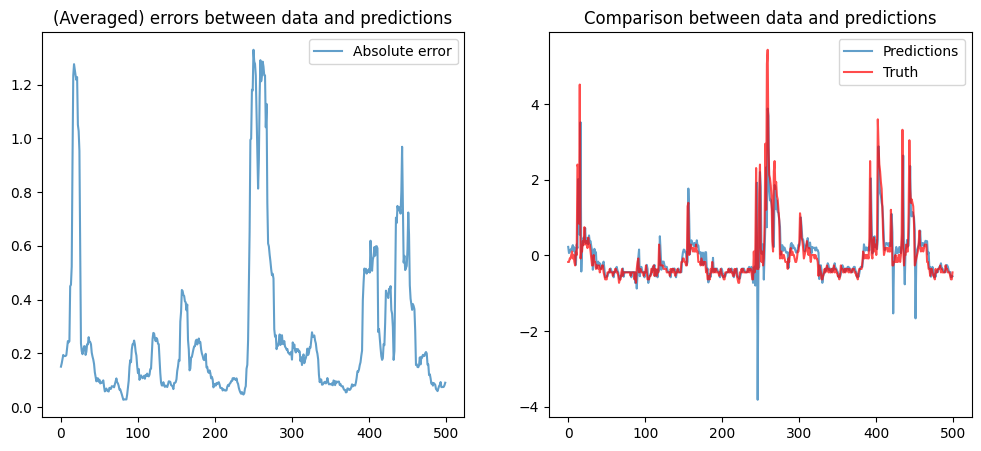

In [15]:
n_samples = 10_000
seq_x = np.array(df["Appliances"][:n_samples].tolist())
predict_univariate(x=seq_x,online=True,plot_tree=True)

### Bivariate predictions 

In-sample MSE (full dataset): 0.466468
In-sample MAE (full dataset): 0.296388
In-sample MASE (full dataset): 0.975356


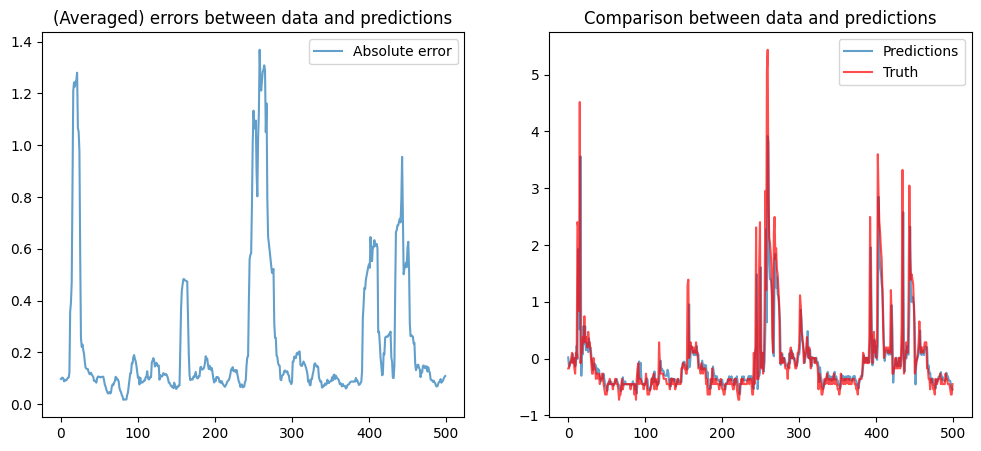

In [16]:
n_samples = 10_000
seq_x = np.array(df["Appliances"][:n_samples].tolist())
seq_y = np.array(df["T_out"][:n_samples].tolist())
predict_bivariate(seq_x,seq_y,online=True,plot_tree=True)

## 2. Household Electric Power Consumption 

The goal is to predict the Global_active_power, from Voltage. 

https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption

In [17]:
df = pd.read_csv(
    "data/household_power_consumption.txt",
    sep=";",         
    na_values="?",   
    low_memory=False 
)

df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True
)
cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

df[cols] = df[cols].astype(float)
df = df.dropna()
df = df[["datetime", "Global_active_power", "Voltage"]]
df = df.sort_values("datetime").reset_index(drop=True)
df.head()

,datetime,Global_active_power,Voltage
0,2006-12-16 17:24:00,4.216,234.84
1,2006-12-16 17:25:00,5.360,233.63
2,2006-12-16 17:26:00,5.374,233.29
3,2006-12-16 17:27:00,5.388,233.74
4,2006-12-16 17:28:00,3.666,235.68


### Univariate prediction

In-sample MSE (full dataset): 0.226895
In-sample MAE (full dataset): 0.261199
In-sample MASE (full dataset): 1.187231


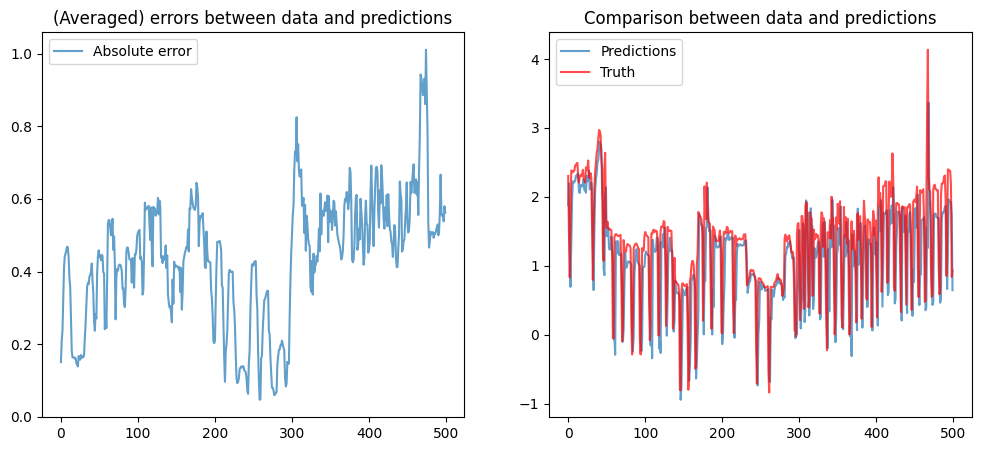

In [21]:
seq_x = np.array(df["Global_active_power"][:n_samples], dtype=float)
seq_y = np.array(df["Voltage"][:n_samples], dtype=float)

predict_bivariate(seq_x,seq_y)

In [22]:
predictions = []
actuals = []

prev_x = x_train[-1]  # dernière valeur vue dans le train

for x_i in seq_x:
    pred = prev_x
    predictions.append(pred)
    actuals.append(x_i)
    prev_x = x_i

predictions = np.array(predictions)
actuals = np.array(actuals)

mae = np.mean(np.abs(predictions - actuals))
mse = np.mean((predictions - actuals) ** 2)

print("Naive baseline - MAE:", mae)
print("Naive baseline - MSE:", mse)

Naive baseline - MAE: 0.21470362317385233
Naive baseline - MSE: 0.2578412413116044


## 3. Données de santés

# Analyse avec y, vibe-coded

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_bivariate_predictions(seq_x, seq_y, predictions, actuals, start_idx=0, window_plot=500):
    """
    seq_x, seq_y : séries complètes
    predictions, actuals : prédictions faites sur une sous-partie de la série
    start_idx : indice dans la série complète correspondant au début des prédictions
    """

    pred = np.asarray(predictions)
    act = np.asarray(actuals)

    # segment aligné de y correspondant aux prédictions
    y_seg = np.asarray(seq_y[start_idx:start_idx + len(pred)])
    x_seg = np.asarray(seq_x[start_idx:start_idx + len(pred)])

    # variations de y
    dy = np.diff(y_seg, prepend=y_seg[0])

    # seuil "forte variation" : 95e percentile des variations absolues
    shock_threshold = np.quantile(np.abs(dy), 0.95)
    shock_mask = np.abs(dy) >= shock_threshold
    shock_idx = np.where(shock_mask)[0]

    # erreurs
    errors = np.abs(pred - act)

    # fenêtre affichée
    n = len(pred)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    plt.figure(figsize=(14, 10))

    # 1) x réel vs prédit
    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(idx, act[s:n], label="x vrai", alpha=0.8)
    ax1.plot(idx, pred[s:n], label="x prédit", alpha=0.8)
    for i in shock_idx:
        if s <= i < n:
            ax1.axvline(i, linestyle="--", alpha=0.2)
    ax1.legend()
    ax1.set_title("x vrai / x prédit + chocs de y")

    # 2) y et ses variations
    ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    ax2.plot(idx, y_seg[s:n], label="y", alpha=0.8)
    shock_idx_window = [i for i in shock_idx if s <= i < n]
    ax2.scatter(shock_idx_window, y_seg[shock_idx_window], label="fortes variations de y", s=20)
    for i in shock_idx:
        if s <= i < n:
            ax2.axvline(i, linestyle="--", alpha=0.2)
    ax2.legend()
    ax2.set_title("Série y utilisée pour le contexte")

    # 3) erreur absolue
    ax3 = plt.subplot(3, 1, 3, sharex=ax1)
    ax3.plot(idx, errors[s:n], label="|erreur|", alpha=0.8)
    for i in shock_idx:
        if s <= i < n:
            ax3.axvline(i, linestyle="--", alpha=0.2)
    ax3.legend()
    ax3.set_title("Erreur absolue")

    plt.tight_layout()
    plt.show()

    return {
        "dy": dy,
        "shock_threshold": shock_threshold,
        "shock_idx": shock_idx,
        "errors":  errors ,
    }

def compare_errors_on_y_shocks(errors, dy, q=0.95):
    errors = np.asarray(errors)
    dy = np.asarray(dy)

    threshold = np.quantile(np.abs(dy), q)
    shock_mask = np.abs(dy) >= threshold
    normal_mask = ~shock_mask

    mean_error_shock = errors[shock_mask].mean() if shock_mask.any() else np.nan
    mean_error_normal = errors[normal_mask].mean() if normal_mask.any() else np.nan

    print(f"Seuil choc |Δy| (quantile {q:.2f}) : {threshold:.4f}")
    print(f"MAE pendant chocs de y        : {mean_error_shock:.4f}")
    print(f"MAE hors chocs de y           : {mean_error_normal:.4f}")
    print(f"Ratio choc / normal           : {mean_error_shock / mean_error_normal:.4f}")

    return {
        "threshold": threshold,
        "mean_error_shock": mean_error_shock,
        "mean_error_normal": mean_error_normal,
        "ratio": mean_error_shock / mean_error_normal,
    }

def y_bins_and_shocks(seq_y, quantizer):
    yq = np.array([quantizer.quantizers[1].quantize(v) for v in seq_y])
    dy = np.diff(seq_y, prepend=seq_y[0])
    y_bin_change = np.diff(yq, prepend=yq[0]) != 0
    return yq, dy, y_bin_change

def plot_y_bins(seq_y, quantizer, window_plot=500):
    yq, dy, y_bin_change = y_bins_and_shocks(seq_y, quantizer)

    n = len(seq_y)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    plt.figure(figsize=(12, 6))

    ax1 = plt.subplot(2, 1, 1)
    ax1.plot(idx, seq_y[s:n], label="y")
    changes = np.where(y_bin_change[s:n])[0] + s
    ax1.scatter(changes, np.array(seq_y)[changes], label="changement de bin y", s=20)
    ax1.legend()
    ax1.set_title("y et changements de quantification")

    ax2 = plt.subplot(2, 1, 2, sharex=ax1)
    ax2.step(idx, yq[s:n], where="post", label="bin(y)")
    ax2.legend()
    ax2.set_title("Quantification de y")

    plt.tight_layout()
    plt.show()

    

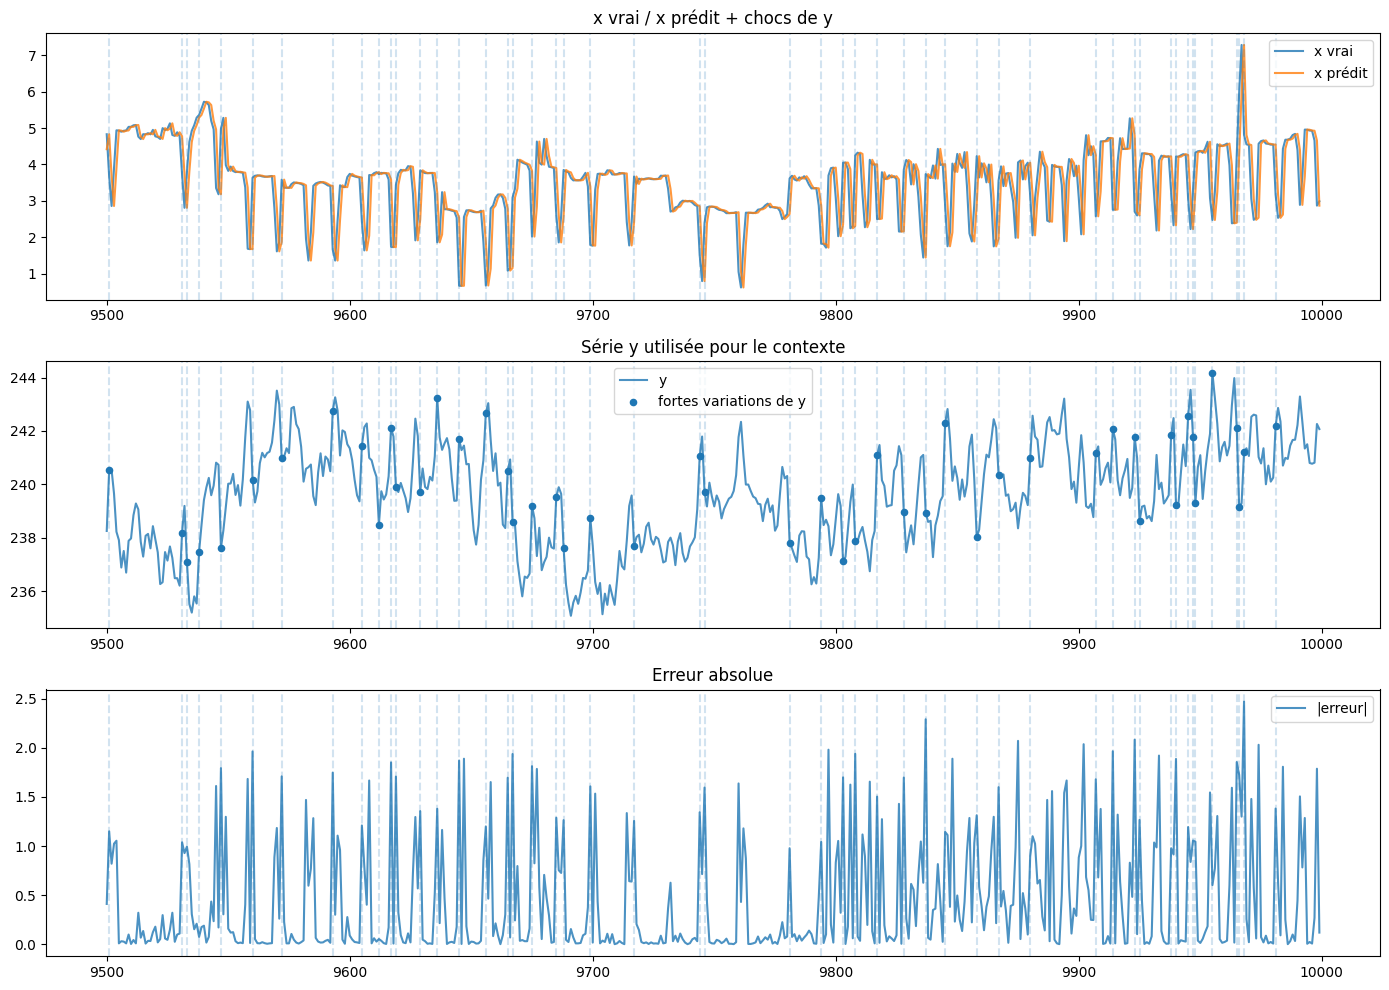

Seuil choc |Δy| (quantile 0.95) : 1.7400
MAE pendant chocs de y        : 1.3134
MAE hors chocs de y           : 0.1564
Ratio choc / normal           : 8.3983


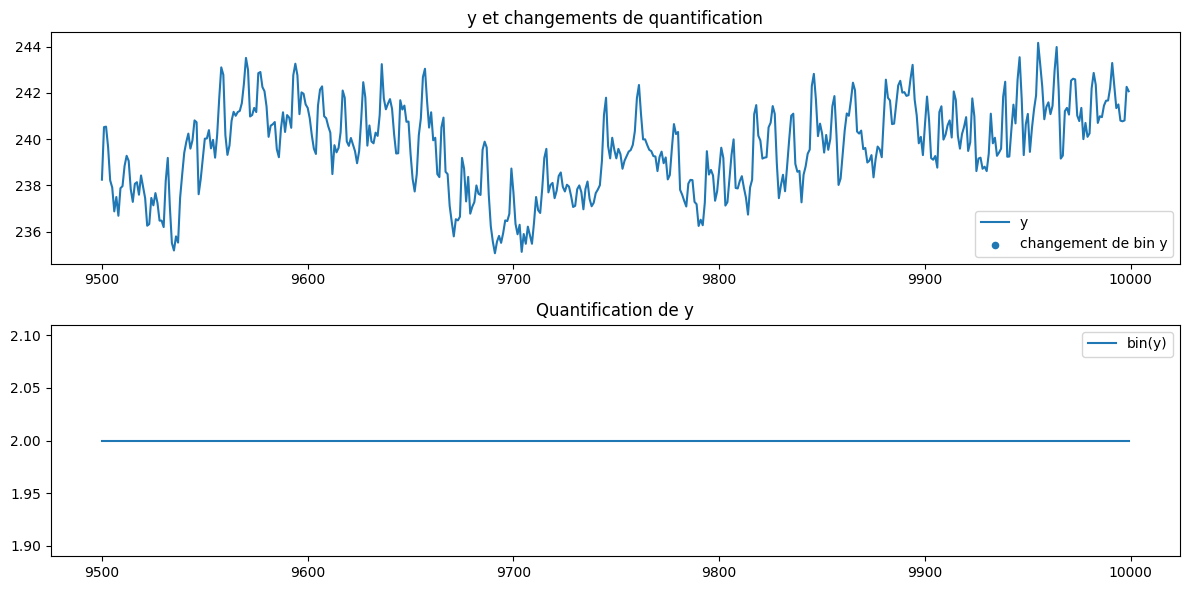

In [25]:
results = analyze_bivariate_predictions(
    seq_x=seq_x,
    seq_y=seq_y,
    predictions=predictions,
    actuals=actuals,
    start_idx=0,
    window_plot=500
)

compare_errors_on_y_shocks(results["errors"], results["dy"], q=0.95)
plot_y_bins(seq_y, bq, window_plot=500)

In [26]:
import numpy as np
import matplotlib.pyplot as plt

from ctw.models import Quantizer, LiveARTree, BivariateQuantizer, BivariateARTree


def fit_predict_univariate_eval(
    seq_x,
    split=0.7,
    order=2,
    max_depth=2,
    beta=0.5,
    constant_term=True,
    n_passes_train=4,
    online=False,
):
    x = np.asarray(seq_x, dtype=float)
    n = len(x)
    split_idx = int(split * n)

    x_train_raw = x[:split_idx]
    x_test_raw = x[split_idx:]

    # standardisation sur train uniquement
    mu_x = x_train_raw.mean()
    std_x = x_train_raw.std()
    x_scaled = (x - mu_x) / std_x
    x_train = x_scaled[:split_idx]
    x_test = x_scaled[split_idx:]

    quantizer = Quantizer(thresholds=np.quantile(x_train, [0.33, 0.66]))
    tree = LiveARTree(
        max_depth=max_depth,
        order=order,
        constant_term=constant_term,
        quantizer=quantizer,
        beta=beta,
    )

    # fit train
    for _ in range(n_passes_train):
        for x_i in x_train:
            tree.observe(float(x_i))

    predictions_scaled = []
    actuals_scaled = []

    # historique glissant, même en offline
    x_seen = list(x_train)

    for x_i in x_test:
        history = np.array(x_seen[-order:], dtype=float)
        pred = tree.predict(history)
        predictions_scaled.append(float(pred))
        actuals_scaled.append(float(x_i))

        x_seen.append(float(x_i))
        if online:
            tree.observe(float(x_i))

    predictions_scaled = np.asarray(predictions_scaled)
    actuals_scaled = np.asarray(actuals_scaled)

    # retour en unités originales de x pour interpréter la MAE
    predictions = predictions_scaled * std_x + mu_x
    actuals = actuals_scaled * std_x + mu_x
    errors = np.abs(predictions - actuals)

    return {
        "model": "univariate",
        "split_idx": split_idx,
        "predictions": predictions,
        "actuals": actuals,
        "errors": errors,
        "x_test_raw": x_test_raw,
        "x_train_raw": x_train_raw,
        "quantizer": quantizer,
        "tree": tree,
    }


def fit_predict_bivariate_eval(
    seq_x,
    seq_y,
    split=0.7,
    order=2,
    max_depth=3,
    beta=0.5,
    constant_term=False,
    online=False,
):
    x = np.asarray(seq_x, dtype=float)
    y = np.asarray(seq_y, dtype=float)
    n = len(x)
    split_idx = int(split * n)

    x_train_raw = x[:split_idx]
    x_test_raw = x[split_idx:]
    y_train_raw = y[:split_idx]
    y_test_raw = y[split_idx:]

    # standardisation sur train uniquement
    mu_x = x_train_raw.mean()
    std_x = x_train_raw.std()
    mu_y = y_train_raw.mean()
    std_y = y_train_raw.std()

    x_scaled = (x - mu_x) / std_x
    y_scaled = (y - mu_y) / std_y

    x_train = x_scaled[:split_idx]
    x_test = x_scaled[split_idx:]
    y_train = y_scaled[:split_idx]
    y_test = y_scaled[split_idx:]

    qx = np.quantile(x_train, [0.33, 0.66])
    qy = np.quantile(y_train, [0.33, 0.66])
    thresholds = np.array([qx, qy], dtype=float)

    bq = BivariateQuantizer(thresholds=thresholds)
    tree = BivariateARTree(
        order=order,
        max_depth=max_depth,
        constant_term=constant_term,
        quantizer=bq,
        beta=beta,
    )

    # fit train
    for x_i, y_i in zip(x_train, y_train):
        tree.observe(float(x_i), float(y_i))

    predictions_scaled = []
    actuals_scaled = []

    # historique glissant, même en offline
    x_seen = list(x_train)
    y_seen = list(y_train)

    hist_len = max(max_depth, order)

    for x_i, y_i in zip(x_test, y_test):
        history = np.array([
            x_seen[-hist_len:],
            y_seen[-hist_len:],
        ], dtype=float)

        pred = tree.predict(history)
        predictions_scaled.append(float(pred))
        actuals_scaled.append(float(x_i))

        x_seen.append(float(x_i))
        y_seen.append(float(y_i))
        if online:
            tree.observe(float(x_i), float(y_i))

    predictions_scaled = np.asarray(predictions_scaled)
    actuals_scaled = np.asarray(actuals_scaled)

    predictions = predictions_scaled * std_x + mu_x
    actuals = actuals_scaled * std_x + mu_x
    errors = np.abs(predictions - actuals)

    return {
        "model": "bivariate",
        "split_idx": split_idx,
        "predictions": predictions,
        "actuals": actuals,
        "errors": errors,
        "x_test_raw": x_test_raw,
        "y_test_raw": y_test_raw,
        "x_train_raw": x_train_raw,
        "y_train_raw": y_train_raw,
        "quantizer": bq,
        "tree": tree,
    }


def compute_lagged_y_shocks(seq_y, split_idx, q=0.95):
    """
    Choc de y aligné avec la prédiction de x_t :
    on utilise ici le dernier choc observable avant de prédire x_t,
    donc |y_{t-1} - y_{t-2}|.
    """
    y = np.asarray(seq_y, dtype=float)
    n_test = len(y) - split_idx

    shock_values = []
    for t in range(split_idx, len(y)):
        if t >= 2:
            shock_values.append(abs(y[t - 1] - y[t - 2]))
        elif t >= 1:
            shock_values.append(abs(y[t - 1] - y[t - 1]))
        else:
            shock_values.append(0.0)

    shock_values = np.asarray(shock_values)
    threshold = np.quantile(shock_values, q)
    shock_mask = shock_values >= threshold
    return shock_values, threshold, shock_mask


def summarize_error_by_mask(errors, mask, label):
    errors = np.asarray(errors)
    mask = np.asarray(mask, dtype=bool)

    mae_sel = errors[mask].mean() if mask.any() else np.nan
    mae_other = errors[~mask].mean() if (~mask).any() else np.nan

    print(f"{label}")
    print(f"  n zone          : {mask.sum()}")
    print(f"  MAE zone        : {mae_sel:.6f}")
    print(f"  MAE hors zone   : {mae_other:.6f}")
    print(f"  ratio zone/hors : {mae_sel / mae_other:.6f}" if np.isfinite(mae_sel) and np.isfinite(mae_other) and mae_other != 0 else "  ratio zone/hors : nan")

    return {
        "n": int(mask.sum()),
        "mae_zone": mae_sel,
        "mae_other": mae_other,
        "ratio": mae_sel / mae_other if np.isfinite(mae_sel) and np.isfinite(mae_other) and mae_other != 0 else np.nan,
    }


def compare_univariate_bivariate_on_y(
    seq_x,
    seq_y,
    split=0.7,
    q_shock=0.95,
    top_k=20,
    online=False,
    plot_window=300,
):
    uni = fit_predict_univariate_eval(seq_x, split=split, online=online)
    bi = fit_predict_bivariate_eval(seq_x, seq_y, split=split, online=online)

    # alignement
    pred_u = uni["predictions"]
    pred_b = bi["predictions"]
    act = bi["actuals"]

    err_u = np.abs(pred_u - act)
    err_b = np.abs(pred_b - act)
    gain = err_u - err_b

    mae_u = err_u.mean()
    mae_b = err_b.mean()

    print("MAE globale")
    print(f"  univarié : {mae_u:.6f}")
    print(f"  bivarié  : {mae_b:.6f}")
    print(f"  gain abs : {mae_u - mae_b:.6f}")
    print(f"  gain rel : {(mae_u - mae_b) / mae_u * 100:.2f} %")

    # chocs de y observables avant la prédiction
    shock_values, shock_threshold, shock_mask = compute_lagged_y_shocks(seq_y, bi["split_idx"], q=q_shock)

    print("")
    print(f"Chocs de y")
    print(f"  seuil |Δy_lag| q={q_shock:.2f} : {shock_threshold:.6f}")

    stats_uni_shock = summarize_error_by_mask(err_u, shock_mask, "Univarié sur chocs de y")
    stats_bi_shock = summarize_error_by_mask(err_b, shock_mask, "Bivarié sur chocs de y")

    print("")
    print("Comparaison directe sur chocs de y")
    print(f"  MAE uni choc : {err_u[shock_mask].mean():.6f}" if shock_mask.any() else "  MAE uni choc : nan")
    print(f"  MAE bi choc  : {err_b[shock_mask].mean():.6f}" if shock_mask.any() else "  MAE bi choc  : nan")
    if shock_mask.any():
        print(f"  gain choc    : {(err_u[shock_mask].mean() - err_b[shock_mask].mean()):.6f}")

    # top erreurs univariées
    top_k = min(top_k, len(err_u))
    top_idx = np.argsort(err_u)[-top_k:]
    top_mask = np.zeros_like(err_u, dtype=bool)
    top_mask[top_idx] = True

    print("")
    print(f"Top {top_k} plus grosses erreurs du modèle univarié")
    print(f"  MAE uni topK : {err_u[top_mask].mean():.6f}")
    print(f"  MAE bi topK  : {err_b[top_mask].mean():.6f}")
    print(f"  gain topK    : {(err_u[top_mask].mean() - err_b[top_mask].mean()):.6f}")
    print(f"  points où bi fait mieux sur topK : {(gain[top_mask] > 0).mean() * 100:.1f} %")

    # visualisation
    n = len(act)
    s = max(0, n - plot_window)
    idx = np.arange(s, n)

    plt.figure(figsize=(14, 10))

    ax1 = plt.subplot(4, 1, 1)
    ax1.plot(idx, act[s:], label="x vrai", alpha=0.8)
    ax1.plot(idx, pred_u[s:], label="pred uni", alpha=0.8)
    ax1.plot(idx, pred_b[s:], label="pred bi", alpha=0.8)
    ax1.legend()
    ax1.set_title("Comparaison prédictions")

    ax2 = plt.subplot(4, 1, 2, sharex=ax1)
    y_test = np.asarray(seq_y[bi["split_idx"]:])
    ax2.plot(idx, y_test[s:], label="y test", alpha=0.8)
    shock_idx = np.where(shock_mask)[0]
    shock_idx = shock_idx[(shock_idx >= s) & (shock_idx < n)]
    if len(shock_idx) > 0:
        ax2.scatter(shock_idx, y_test[shock_idx], s=20, label="chocs de y")
    ax2.legend()
    ax2.set_title("Signal y et chocs")

    ax3 = plt.subplot(4, 1, 3, sharex=ax1)
    ax3.plot(idx, err_u[s:], label="|err| uni", alpha=0.8)
    ax3.plot(idx, err_b[s:], label="|err| bi", alpha=0.8)
    ax3.legend()
    ax3.set_title("Erreurs absolues")

    ax4 = plt.subplot(4, 1, 4, sharex=ax1)
    ax4.plot(idx, gain[s:], label="gain = err_uni - err_bi", alpha=0.8)
    ax4.axhline(0.0, color="black", linestyle="--", alpha=0.5)
    ax4.legend()
    ax4.set_title("Gain du bivarié")
    plt.tight_layout()
    plt.show()

    return {
        "uni": uni,
        "bi": bi,
        "actuals": act,
        "pred_uni": pred_u,
        "pred_bi": pred_b,
        "err_uni": err_u,
        "err_bi": err_b,
        "gain": gain,
        "shock_values": shock_values,
        "shock_threshold": shock_threshold,
        "shock_mask": shock_mask,
        "stats_uni_shock": stats_uni_shock,
        "stats_bi_shock": stats_bi_shock,
        "top_idx_uni": top_idx,
    }


MAE globale
  univarié : 0.358779
  bivarié  : 0.352052
  gain abs : 0.006727
  gain rel : 1.88 %

Chocs de y
  seuil |Δy_lag| q=0.95 : 1.940500
Univarié sur chocs de y
  n zone          : 150
  MAE zone        : 0.814615
  MAE hors zone   : 0.334788
  ratio zone/hors : 2.433230
Bivarié sur chocs de y
  n zone          : 150
  MAE zone        : 0.699922
  MAE hors zone   : 0.333743
  ratio zone/hors : 2.097190

Comparaison directe sur chocs de y
  MAE uni choc : 0.814615
  MAE bi choc  : 0.699922
  gain choc    : 0.114694

Top 30 plus grosses erreurs du modèle univarié
  MAE uni topK : 2.422406
  MAE bi topK  : 1.559571
  gain topK    : 0.862835
  points où bi fait mieux sur topK : 86.7 %


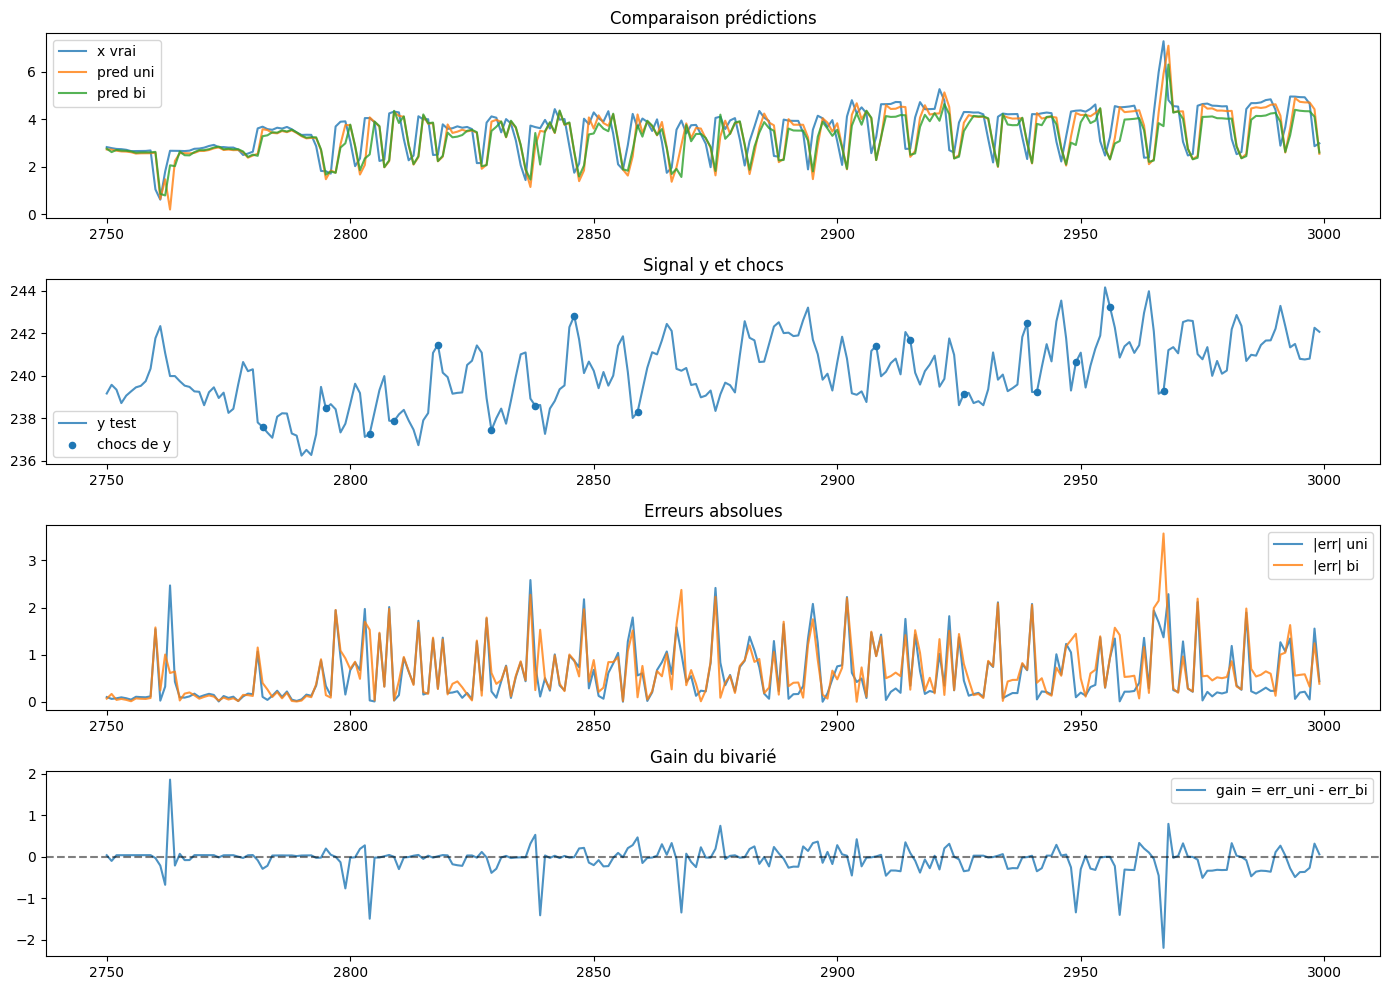

In [27]:
res = compare_univariate_bivariate_on_y(
    seq_x,
    seq_y,
    split=0.7,
    q_shock=0.95,
    top_k=30,
    online=False,
    plot_window=250,
)


In [28]:
import numpy as np
import matplotlib.pyplot as plt

from ctw.models import Quantizer, LiveARTree, BivariateQuantizer, BivariateARTree


def fit_univariate_for_trace(seq_x, split=0.7, order=2, max_depth=2, beta=0.5, constant_term=True, n_passes_train=4):
    x = np.asarray(seq_x, dtype=float)
    split_idx = int(split * len(x))

    x_train_raw = x[:split_idx]
    mu_x = x_train_raw.mean()
    std_x = x_train_raw.std()

    x_scaled = (x - mu_x) / std_x
    x_train = x_scaled[:split_idx]

    q = Quantizer(thresholds=np.quantile(x_train, [0.33, 0.66]))
    tree = LiveARTree(max_depth=max_depth, order=order, constant_term=constant_term, quantizer=q, beta=beta)

    for _ in range(n_passes_train):
        for x_i in x_train:
            tree.observe(float(x_i))

    return {
        "tree": tree,
        "x_scaled": x_scaled,
        "split_idx": split_idx,
        "mu_x": mu_x,
        "std_x": std_x,
        "order": order,
        "max_depth": max_depth,
        "constant_term": constant_term,
        "quantizer": q,
    }


def fit_bivariate_for_trace(seq_x, seq_y, split=0.7, order=2, max_depth=3, beta=0.5, constant_term=False):
    x = np.asarray(seq_x, dtype=float)
    y = np.asarray(seq_y, dtype=float)
    split_idx = int(split * len(x))

    x_train_raw = x[:split_idx]
    y_train_raw = y[:split_idx]

    mu_x = x_train_raw.mean()
    std_x = x_train_raw.std()
    mu_y = y_train_raw.mean()
    std_y = y_train_raw.std()

    x_scaled = (x - mu_x) / std_x
    y_scaled = (y - mu_y) / std_y

    x_train = x_scaled[:split_idx]
    y_train = y_scaled[:split_idx]

    qx = np.quantile(x_train, [0.33, 0.66])
    qy = np.quantile(y_train, [0.33, 0.66])
    bq = BivariateQuantizer(thresholds=np.array([qx, qy], dtype=float))

    tree = BivariateARTree(
        order=order,
        max_depth=max_depth,
        constant_term=constant_term,
        quantizer=bq,
        beta=beta,
    )

    for x_i, y_i in zip(x_train, y_train):
        tree.observe(float(x_i), float(y_i))

    return {
        "tree": tree,
        "x_scaled": x_scaled,
        "y_scaled": y_scaled,
        "split_idx": split_idx,
        "mu_x": mu_x,
        "std_x": std_x,
        "mu_y": mu_y,
        "std_y": std_y,
        "order": order,
        "max_depth": max_depth,
        "constant_term": constant_term,
        "quantizer": bq,
    }


def _select_node_univariate(tree, history):
    history = np.asarray(history, dtype=float)[::-1]
    context_to_navigate = [tree.quantizer.quantize(v) for v in history[:tree.max_depth]][::-1]

    node = tree.tree.root
    depth = 0
    while not node.data["leaf_cbct"] and depth < tree.max_depth:
        context_value = context_to_navigate[depth]
        found_child = False
        for child in node.children:
            if child.value == context_value:
                node = child
                found_child = True
                break
        if not found_child:
            break
        depth += 1
    return node


def _select_node_bivariate(tree, history):
    history = np.asarray(history, dtype=float)[:, ::-1]
    bi_context = [history[:tree.max_depth, k] for k in range(history.shape[1])]
    context_to_navigate = [tree.quantizer.quantize(v) for v in bi_context][::-1]

    node = tree.tree.root
    depth = 0
    while not node.data["leaf_cbct"] and depth < tree.max_depth:
        context_value = context_to_navigate[depth]
        found_child = False
        for child in node.children:
            if child.value == context_value:
                node = child
                found_child = True
                break
        if not found_child:
            break
        depth += 1
    return node


def trace_univariate_regimes(seq_x, split=0.7, online=False):
    fit = fit_univariate_for_trace(seq_x, split=split)
    tree = fit["tree"]
    x_scaled = fit["x_scaled"]
    split_idx = fit["split_idx"]
    order = fit["order"]

    preds = []
    actuals = []
    contexts = []
    depths = []
    coeffs = []
    vars_ = []

    x_seen = list(x_scaled[:split_idx])

    for t in range(split_idx, len(x_scaled)):
        history = np.array(x_seen[-order:], dtype=float)
        node = _select_node_univariate(tree, history)
        pred = tree.predict(history)

        preds.append(pred)
        actuals.append(x_scaled[t])
        contexts.append(tuple(node.context))
        depths.append(len(node.context))
        coeffs.append(np.array(node.data["ms"]).reshape(-1).copy())
        vars_.append(float(np.asarray(node.data["var"]).squeeze()))

        x_seen.append(float(x_scaled[t]))
        if online:
            tree.observe(float(x_scaled[t]))

    preds = np.asarray(preds) * fit["std_x"] + fit["mu_x"]
    actuals = np.asarray(actuals) * fit["std_x"] + fit["mu_x"]

    return {
        "predictions": preds,
        "actuals": actuals,
        "errors": np.abs(preds - actuals),
        "contexts": contexts,
        "depths": np.asarray(depths),
        "coeffs": coeffs,
        "vars": np.asarray(vars_),
        "split_idx": split_idx,
    }


def trace_bivariate_regimes(seq_x, seq_y, split=0.7, online=False):
    fit = fit_bivariate_for_trace(seq_x, seq_y, split=split)
    tree = fit["tree"]
    x_scaled = fit["x_scaled"]
    y_scaled = fit["y_scaled"]
    split_idx = fit["split_idx"]
    max_depth = fit["max_depth"]
    order = fit["order"]

    preds = []
    actuals = []
    contexts = []
    depths = []
    coeffs = []
    vars_ = []
    y_bin_lag = []

    x_seen = list(x_scaled[:split_idx])
    y_seen = list(y_scaled[:split_idx])

    hist_len = max(max_depth, order)

    for t in range(split_idx, len(x_scaled)):
        history = np.array([
            x_seen[-hist_len:],
            y_seen[-hist_len:],
        ], dtype=float)

        node = _select_node_bivariate(tree, history)
        pred = tree.predict(history)

        preds.append(pred)
        actuals.append(x_scaled[t])
        contexts.append(tuple(node.context))
        depths.append(len(node.context))
        coeffs.append(np.array(node.data["ms"]).reshape(-1).copy())
        vars_.append(float(np.asarray(node.data["var"]).squeeze()))

        y_last = y_seen[-1]
        y_bin_lag.append(tree.quantizer.quantizers[1].quantize(y_last))

        x_seen.append(float(x_scaled[t]))
        y_seen.append(float(y_scaled[t]))
        if online:
            tree.observe(float(x_scaled[t]), float(y_scaled[t]))

    preds = np.asarray(preds) * fit["std_x"] + fit["mu_x"]
    actuals = np.asarray(actuals) * fit["std_x"] + fit["mu_x"]

    return {
        "predictions": preds,
        "actuals": actuals,
        "errors": np.abs(preds - actuals),
        "contexts": contexts,
        "depths": np.asarray(depths),
        "coeffs": coeffs,
        "vars": np.asarray(vars_),
        "y_bin_lag": np.asarray(y_bin_lag),
        "split_idx": split_idx,
    }


def context_to_regime_ids(contexts):
    mapping = {}
    ids = []
    next_id = 0
    for ctx in contexts:
        if ctx not in mapping:
            mapping[ctx] = next_id
            next_id += 1
        ids.append(mapping[ctx])
    return np.asarray(ids), mapping


def regime_switch_mask(regime_ids):
    regime_ids = np.asarray(regime_ids)
    if len(regime_ids) == 0:
        return np.array([], dtype=bool)
    out = np.zeros(len(regime_ids), dtype=bool)
    out[1:] = regime_ids[1:] != regime_ids[:-1]
    return out


def plot_regime_timeline(actuals, predictions, regime_ids, title="AR regimes over time", window_plot=300):
    actuals = np.asarray(actuals)
    predictions = np.asarray(predictions)
    regime_ids = np.asarray(regime_ids)

    n = len(actuals)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    plt.figure(figsize=(14, 7))

    ax1 = plt.subplot(2, 1, 1)
    ax1.plot(idx, actuals[s:n], label="x vrai", alpha=0.8)
    ax1.plot(idx, predictions[s:n], label="x prédit", alpha=0.8)
    ax1.legend()
    ax1.set_title(title)

    ax2 = plt.subplot(2, 1, 2, sharex=ax1)
    ax2.step(idx, regime_ids[s:n], where="post", label="regime id")
    switches = np.where(regime_switch_mask(regime_ids))[0]
    switches = switches[(switches >= s) & (switches < n)]
    if len(switches) > 0:
        ax2.scatter(switches, regime_ids[switches], s=20, label="switch")
    ax2.legend()
    ax2.set_title("Régime AR sélectionné")

    plt.tight_layout()
    plt.show()


def plot_regime_zones(actuals, predictions, regime_ids, errors=None, window_plot=300, title="Zones de régimes AR"):
    actuals = np.asarray(actuals)
    predictions = np.asarray(predictions)
    regime_ids = np.asarray(regime_ids)
    errors = np.abs(predictions - actuals) if errors is None else np.asarray(errors)

    n = len(actuals)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    unique_regimes = np.unique(regime_ids)
    cmap = plt.cm.get_cmap("tab20", max(20, len(unique_regimes)))
    color_map = {r: cmap(i % cmap.N) for i, r in enumerate(unique_regimes)}

    plt.figure(figsize=(14, 9))

    ax1 = plt.subplot(3, 1, 1)
    start = s
    current = regime_ids[s]
    for t in range(s + 1, n + 1):
        if t == n or regime_ids[t] != current:
            ax1.axvspan(start, t - 1, color=color_map[current], alpha=0.18)
            if t < n:
                start = t
                current = regime_ids[t]
    ax1.plot(idx, actuals[s:n], color="black", label="x vrai", linewidth=1.5)
    ax1.plot(idx, predictions[s:n], color="tab:red", label="x prédit", alpha=0.8)
    ax1.legend()
    ax1.set_title(title)

    ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    ax2.step(idx, regime_ids[s:n], where="post", color="tab:blue")
    ax2.set_title("Identifiant du régime")

    ax3 = plt.subplot(3, 1, 3, sharex=ax1)
    ax3.plot(idx, errors[s:n], color="tab:orange")
    ax3.set_title("Erreur absolue")

    plt.tight_layout()
    plt.show()


def compare_regime_interpretation(seq_x, seq_y, split=0.7, online=False, window_plot=300):
    uni = trace_univariate_regimes(seq_x, split=split, online=online)
    bi = trace_bivariate_regimes(seq_x, seq_y, split=split, online=online)

    reg_u, map_u = context_to_regime_ids(uni["contexts"])
    reg_b, map_b = context_to_regime_ids(bi["contexts"])

    sw_u = regime_switch_mask(reg_u)
    sw_b = regime_switch_mask(reg_b)

    err_u = uni["errors"]
    err_b = bi["errors"]
    gain = err_u - err_b

    y_test = np.asarray(seq_y[bi["split_idx"]:])
    y_bin = bi["y_bin_lag"]
    y_bin_switch = regime_switch_mask(y_bin)

    print("MAE globale")
    print(f"  univarié : {err_u.mean():.6f}")
    print(f"  bivarié  : {err_b.mean():.6f}")
    print(f"  gain     : {(err_u.mean() - err_b.mean()):.6f}")

    print("")
    print("Switch de régime")
    print(f"  nb switch uni : {sw_u.sum()}")
    print(f"  nb switch bi  : {sw_b.sum()}")

    only_bi_switch = sw_b & (~sw_u)
    if only_bi_switch.any():
        print("")
        print("Quand le bivarié change de régime et pas l'univarié")
        print(f"  MAE uni : {err_u[only_bi_switch].mean():.6f}")
        print(f"  MAE bi  : {err_b[only_bi_switch].mean():.6f}")
        print(f"  gain    : {(err_u[only_bi_switch].mean() - err_b[only_bi_switch].mean()):.6f}")
        print(f"  part des points où bi aide : {(gain[only_bi_switch] > 0).mean() * 100:.1f} %")

    if y_bin_switch.any():
        print("")
        print("Lien avec les changements de bin de y")
        print(f"  P(switch bi | switch bin(y)) = {(sw_b[y_bin_switch]).mean():.3f}")
        print(f"  P(switch uni | switch bin(y)) = {(sw_u[y_bin_switch]).mean():.3f}")
        print(f"  gain moyen bi sur switch bin(y) = {gain[y_bin_switch].mean():.6f}")

    plot_regime_timeline(
        uni["actuals"],
        uni["predictions"],
        reg_u,
        title="Régimes AR univariés",
        window_plot=window_plot,
    )

    plot_regime_timeline(
        bi["actuals"],
        bi["predictions"],
        reg_b,
        title="Régimes AR bivariés",
        window_plot=window_plot,
    )

    plot_regime_zones(
        bi["actuals"],
        bi["predictions"],
        reg_b,
        errors=bi["errors"],
        window_plot=window_plot,
        title="Zones de régimes AR du modèle bivarié",
    )

    plt.figure(figsize=(14, 8))

    n = len(y_test)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(idx, y_test[s:n], label="y", alpha=0.8)
    sw_idx = np.where(sw_b)[0]
    sw_idx = sw_idx[(sw_idx >= s) & (sw_idx < n)]
    if len(sw_idx) > 0:
        ax1.scatter(sw_idx, y_test[sw_idx], s=20, label="switch régime bi")
    ax1.legend()
    ax1.set_title("y et changements de régime bivarié")

    ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    ax2.step(idx, y_bin[s:n], where="post", label="bin(y_{t-1})")
    y_sw_idx = np.where(y_bin_switch)[0]
    y_sw_idx = y_sw_idx[(y_sw_idx >= s) & (y_sw_idx < n)]
    if len(y_sw_idx) > 0:
        ax2.scatter(y_sw_idx, y_bin[y_sw_idx], s=20, label="switch bin(y)")
    ax2.legend()
    ax2.set_title("Quantification de y")

    ax3 = plt.subplot(3, 1, 3, sharex=ax1)
    ax3.plot(idx, gain[s:n], label="gain = err_uni - err_bi", alpha=0.8)
    ax3.axhline(0.0, color="black", linestyle="--", alpha=0.5)
    ax3.legend()
    ax3.set_title("Gain du bivarié")

    plt.tight_layout()
    plt.show()

    return {
        "uni": uni,
        "bi": bi,
        "regime_ids_uni": reg_u,
        "regime_ids_bi": reg_b,
        "switch_uni": sw_u,
        "switch_bi": sw_b,
        "y_bin": y_bin,
        "y_bin_switch": y_bin_switch,
        "gain": gain,
        "contexts_uni_map": map_u,
        "contexts_bi_map": map_b,
    }


MAE globale
  univarié : 0.358779
  bivarié  : 0.352052
  gain     : 0.006727

Switch de régime
  nb switch uni : 672
  nb switch bi  : 913

Quand le bivarié change de régime et pas l'univarié
  MAE uni : 0.310950
  MAE bi  : 0.331466
  gain    : -0.020517
  part des points où bi aide : 48.5 %

Lien avec les changements de bin de y
  P(switch bi | switch bin(y)) = 0.653
  P(switch uni | switch bin(y)) = 0.456
  gain moyen bi sur switch bin(y) = 0.045313


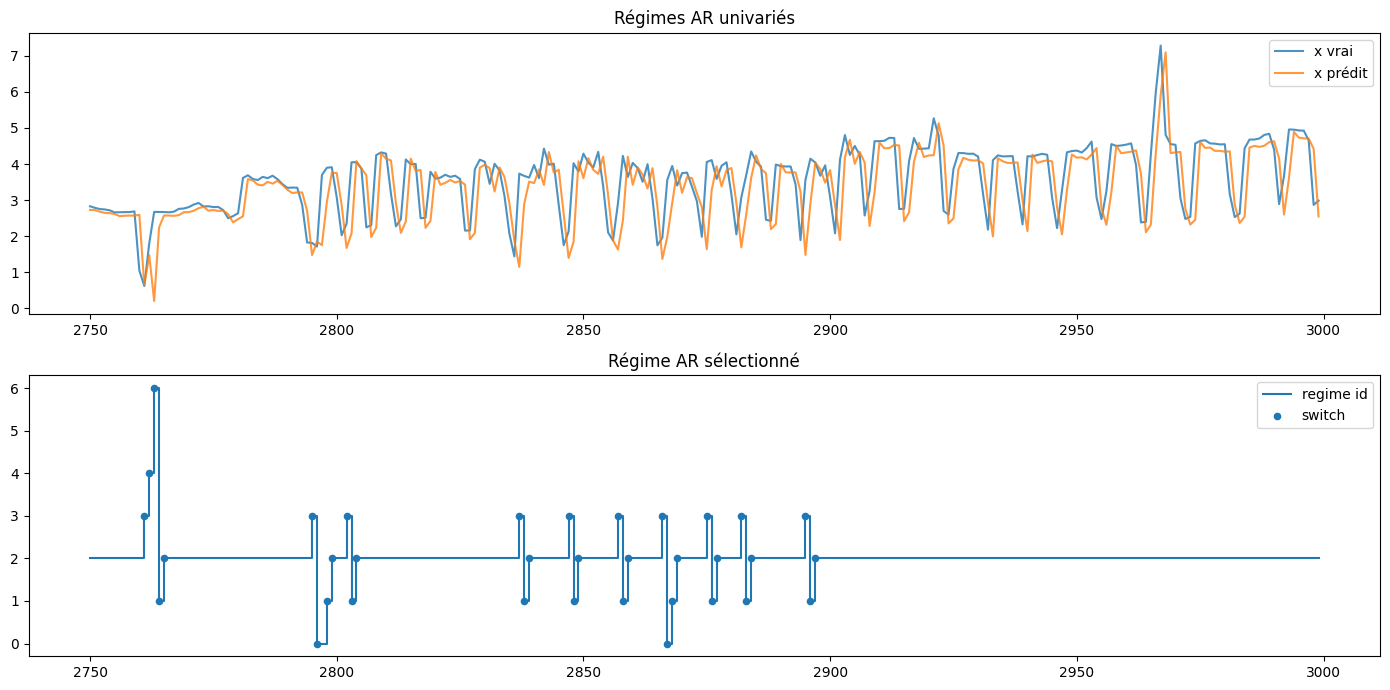

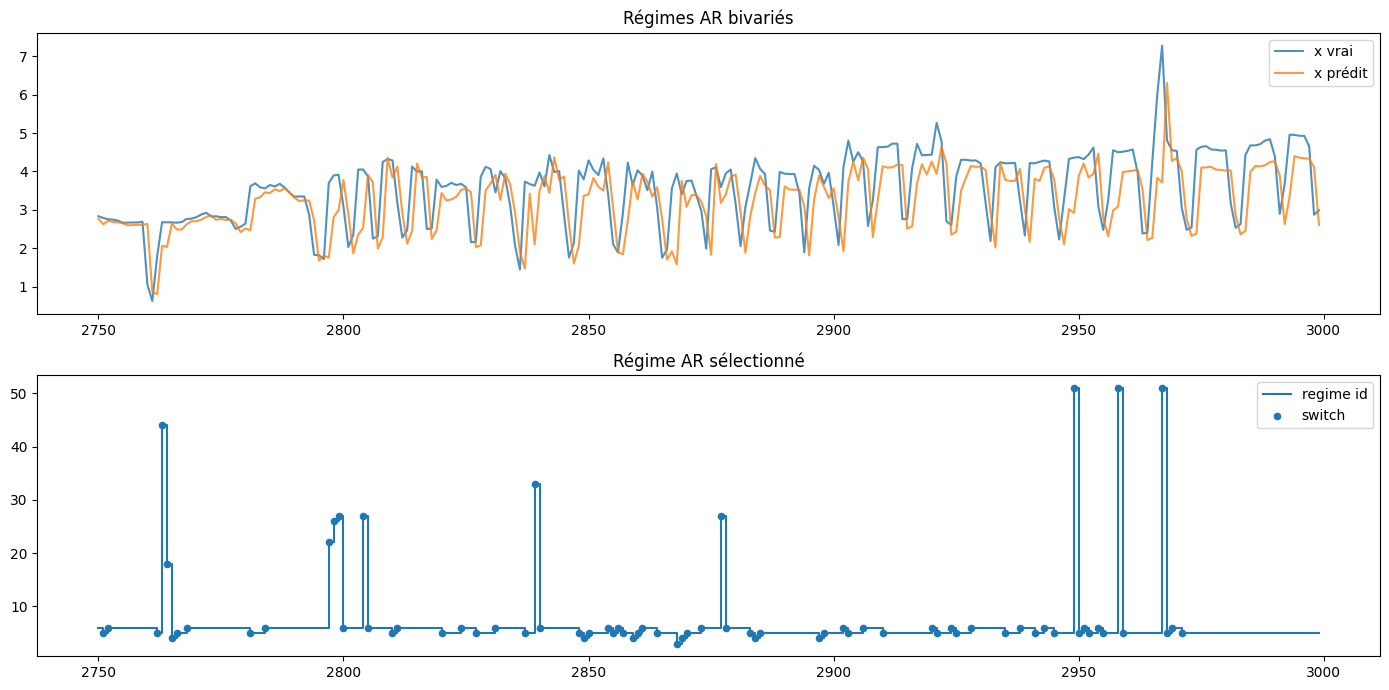

/var/folders/dr/v65kt4vd74b0bqgk5_sy5npr0000gn/T/ipykernel_308/1014631714.py:300: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(20, len(unique_regimes)))


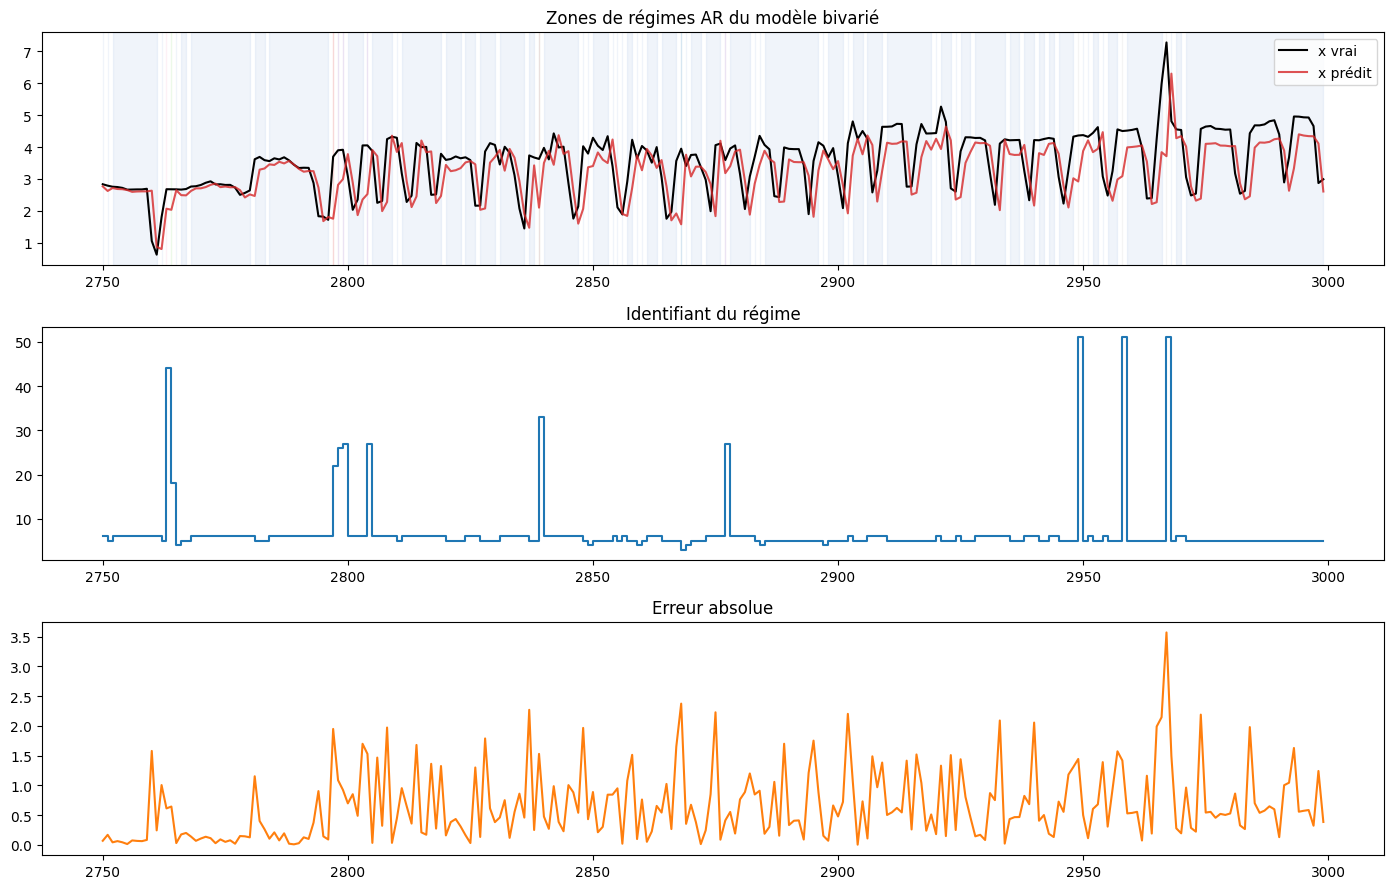

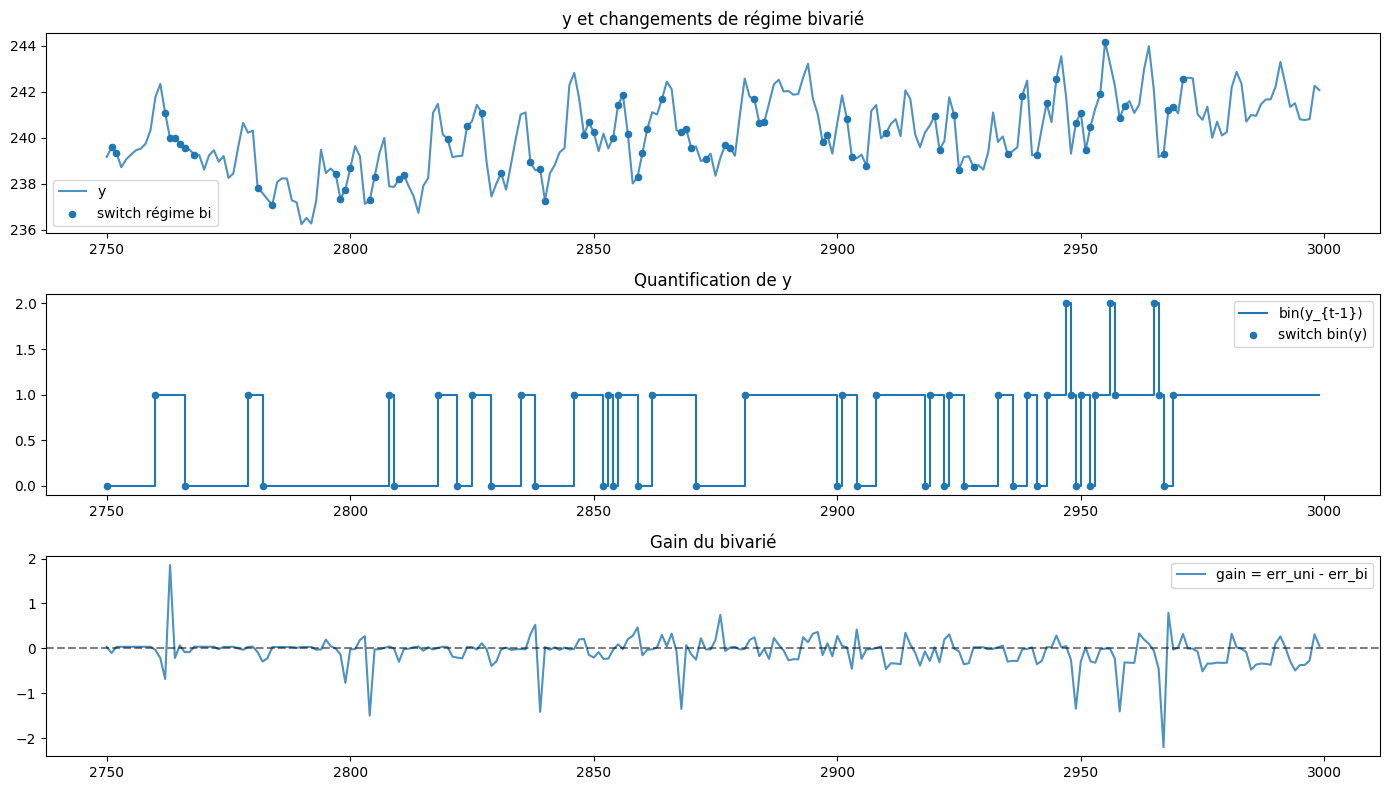

In [29]:
res_reg = compare_regime_interpretation(
    seq_x,
    seq_y,
    split=0.7,
    online=False,
    window_plot=250,
)


In [30]:
import numpy as np
import matplotlib.pyplot as plt


def format_univariate_context(context):
    """
    context: tuple/list d'indices de bins de x
    Ex: (2, 0) -> "[x2 | x0]"
    """
    if context is None or len(context) == 0:
        return "root"
    return "[" + " | ".join(f"x{int(c)}" for c in context) + "]"


def format_bivariate_context(context, quantizer, compact=True):
    """
    context: tuple/list d'indices de bins joints
    quantizer: BivariateQuantizer
    Ex: (7, 3) -> "[(x1,y2) | (x0,y1)]"
    """
    if context is None or len(context) == 0:
        return "root"

    parts = []
    for c in context:
        x_bin, y_bin = quantizer.decode(int(c))
        if compact:
            parts.append(f"(x{x_bin},y{y_bin})")
        else:
            parts.append(f"(bin_x={x_bin}, bin_y={y_bin})")
    return "[" + " | ".join(parts) + "]"


def contexts_to_labels(contexts, quantizer=None, kind="univariate", compact=True):
    labels = []
    for ctx in contexts:
        if kind == "univariate":
            labels.append(format_univariate_context(ctx))
        elif kind == "bivariate":
            labels.append(format_bivariate_context(ctx, quantizer=quantizer, compact=compact))
        else:
            raise ValueError("kind must be 'univariate' or 'bivariate'")
    return labels


def contexts_to_codes_and_labels(contexts, quantizer=None, kind="univariate", compact=True):
    """
    Transforme une suite de contextes en:
    - codes entiers pour plot
    - mapping code -> label lisible
    """
    labels = contexts_to_labels(contexts, quantizer=quantizer, kind=kind, compact=compact)

    label_to_code = {}
    code_to_label = {}
    codes = []
    next_code = 0

    for lab in labels:
        if lab not in label_to_code:
            label_to_code[lab] = next_code
            code_to_label[next_code] = lab
            next_code += 1
        codes.append(label_to_code[lab])

    return np.asarray(codes), code_to_label


def plot_context_timeline(
    actuals,
    predictions,
    contexts,
    quantizer=None,
    kind="univariate",
    window_plot=200,
    compact=True,
    max_tick_labels=15,
    title="Contexte quantifié sélectionné au cours du temps",
):
    """
    Affiche:
    - x vrai / x prédit
    - contexte sélectionné à chaque date, avec labels lisibles

    Si trop de contextes distincts sont visibles, on garde des ids sur l'axe
    et on imprime la table code -> contexte en dessous.
    """
    actuals = np.asarray(actuals)
    predictions = np.asarray(predictions)

    codes, code_to_label = contexts_to_codes_and_labels(
        contexts,
        quantizer=quantizer,
        kind=kind,
        compact=compact,
    )

    n = len(actuals)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    visible_codes = np.unique(codes[s:n])

    plt.figure(figsize=(15, 8))

    ax1 = plt.subplot(2, 1, 1)
    ax1.plot(idx, actuals[s:n], label="x vrai", alpha=0.8)
    ax1.plot(idx, predictions[s:n], label="x prédit", alpha=0.8)
    ax1.legend()
    ax1.set_title(title)

    ax2 = plt.subplot(2, 1, 2, sharex=ax1)
    ax2.step(idx, codes[s:n], where="post", color="tab:blue")
    switch_mask = np.zeros(len(codes), dtype=bool)
    switch_mask[1:] = codes[1:] != codes[:-1]
    switches = np.where(switch_mask)[0]
    switches = switches[(switches >= s) & (switches < n)]
    if len(switches) > 0:
        ax2.scatter(switches, codes[switches], s=18, color="black", label="switch")
        ax2.legend()

    if len(visible_codes) <= max_tick_labels:
        ax2.set_yticks(visible_codes)
        ax2.set_yticklabels([code_to_label[c] for c in visible_codes], fontsize=9)
    else:
        ax2.set_yticks(visible_codes)
        ax2.set_yticklabels([str(c) for c in visible_codes], fontsize=9)

        print("Trop de contextes visibles pour les afficher directement sur l'axe.")
        print("Correspondance code -> contexte :")
        for c in visible_codes:
            print(f"  {c}: {code_to_label[c]}")

    ax2.set_title("Contexte quantifié sélectionné")

    plt.tight_layout()
    plt.show()

    return {
        "codes": codes,
        "code_to_label": code_to_label,
    }


def plot_context_zones(
    actuals,
    predictions,
    contexts,
    errors=None,
    quantizer=None,
    kind="univariate",
    window_plot=200,
    compact=True,
    title="Zones de contexte quantifié",
):
    """
    Variante avec zones colorées par contexte.
    Plus lisible quand on veut voir les blocs temporels.
    """
    actuals = np.asarray(actuals)
    predictions = np.asarray(predictions)
    errors = np.abs(predictions - actuals) if errors is None else np.asarray(errors)

    codes, code_to_label = contexts_to_codes_and_labels(
        contexts,
        quantizer=quantizer,
        kind=kind,
        compact=compact,
    )

    n = len(actuals)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    visible_codes = np.unique(codes[s:n])
    cmap = plt.cm.get_cmap("tab20", max(20, len(visible_codes)))
    color_map = {c: cmap(i % cmap.N) for i, c in enumerate(visible_codes)}

    plt.figure(figsize=(15, 10))

    ax1 = plt.subplot(3, 1, 1)
    start = s
    current = codes[s]
    for t in range(s + 1, n + 1):
        if t == n or codes[t] != current:
            ax1.axvspan(start, t - 1, color=color_map.get(current, "gray"), alpha=0.18)
            if t < n:
                start = t
                current = codes[t]
    ax1.plot(idx, actuals[s:n], color="black", linewidth=1.5, label="x vrai")
    ax1.plot(idx, predictions[s:n], color="tab:red", alpha=0.8, label="x prédit")
    ax1.legend()
    ax1.set_title(title)

    ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    ax2.step(idx, codes[s:n], where="post", color="tab:blue")
    if len(visible_codes) <= 12:
        ax2.set_yticks(visible_codes)
        ax2.set_yticklabels([code_to_label[c] for c in visible_codes], fontsize=9)
    else:
        ax2.set_yticks(visible_codes)
        ax2.set_yticklabels([str(c) for c in visible_codes], fontsize=9)
        print("Correspondance code -> contexte visible :")
        for c in visible_codes:
            print(f"  {c}: {code_to_label[c]}")
    ax2.set_title("Contexte quantifié actif")

    ax3 = plt.subplot(3, 1, 3, sharex=ax1)
    ax3.plot(idx, errors[s:n], color="tab:orange")
    ax3.set_title("Erreur absolue")

    plt.tight_layout()
    plt.show()

    return {
        "codes": codes,
        "code_to_label": code_to_label,
    }


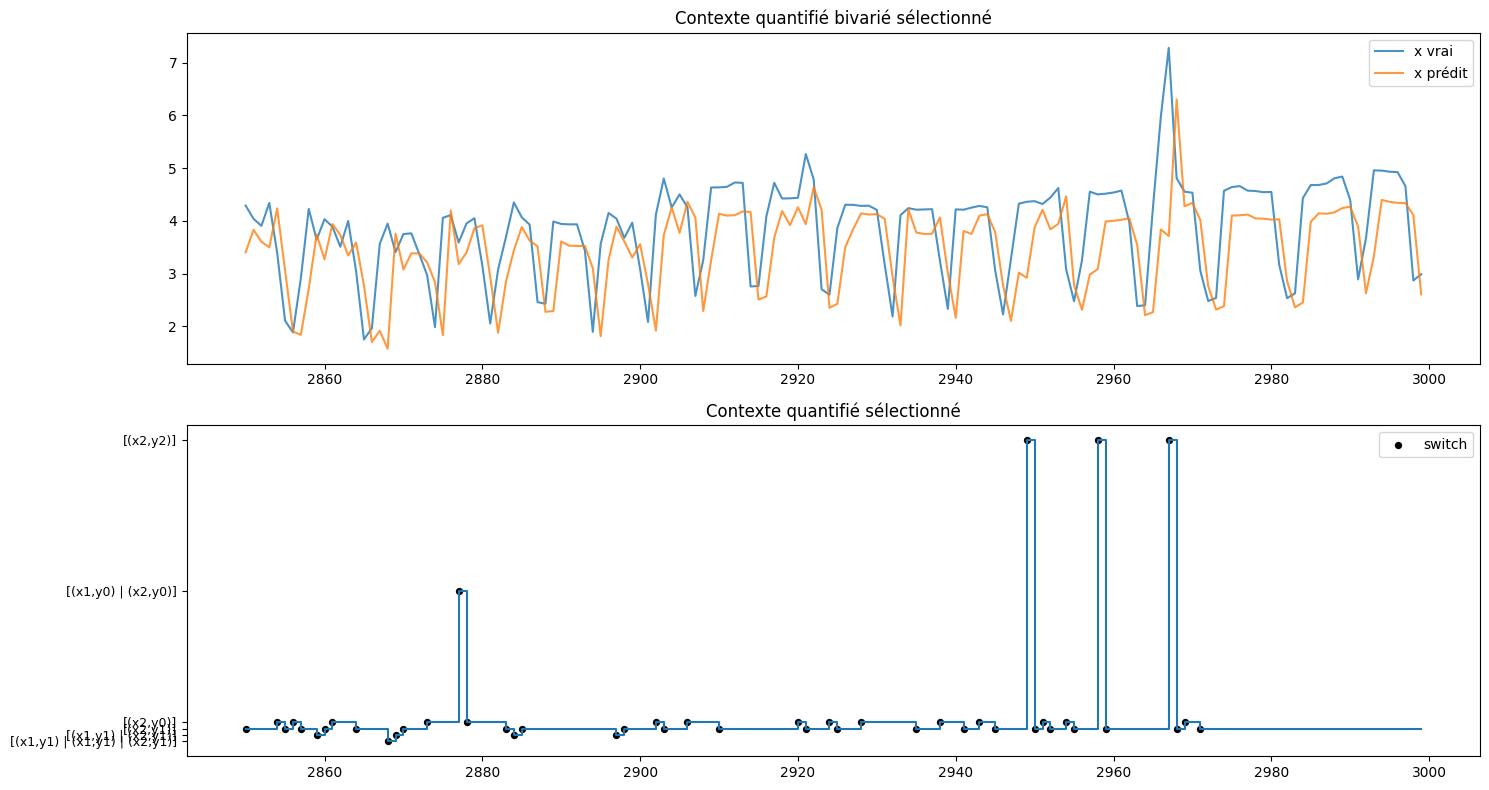

{'codes': array([0, 0, 0, ..., 5, 5, 5], shape=(3000,)),
 'code_to_label': {0: '[(x1,y2) | (x1,y2) | (x1,y2)]',
  1: '[(x1,y2) | (x1,y2) | (x1,y1)]',
  2: '[(x1,y2) | (x1,y1)]',
  3: '[(x1,y1) | (x1,y1) | (x2,y1)]',
  4: '[(x1,y1) | (x2,y1)]',
  5: '[(x2,y1)]',
  6: '[(x2,y0)]',
  7: '[(x1,y1) | (x1,y1) | (x1,y1)]',
  8: '[(x1,y1) | (x1,y1) | (x1,y2)]',
  9: '[(x1,y1) | (x1,y2)]',
  10: '[(x1,y1) | (x1,y1) | (x0,y2)]',
  11: '[(x1,y1) | (x0,y2) | (x0,y2)]',
  12: '[(x0,y2) | (x0,y2) | (x0,y2)]',
  13: '[(x0,y2) | (x0,y2) | (x0,y1)]',
  14: '[(x0,y2) | (x0,y1)]',
  15: '[(x0,y1) | (x0,y1) | (x0,y1)]',
  16: '[(x0,y1) | (x0,y1) | (x0,y2)]',
  17: '[(x0,y1) | (x0,y2)]',
  18: '[(x0,y1) | (x1,y1)]',
  19: '[(x1,y1) | (x1,y1) | (x1,y0)]',
  20: '[(x1,y1) | (x1,y0)]',
  21: '[(x1,y0) | (x1,y1)]',
  22: '[(x1,y0) | (x1,y0) | (x1,y0)]',
  23: '[(x1,y0) | (x1,y0) | (x0,y0)]',
  24: '[(x1,y0) | (x0,y0) | (x0,y0)]',
  25: '[(x0,y0)]',
  26: '[(x1,y0) | (x1,y0) | (x2,y0)]',
  27: '[(x1,y0) | (x2,y

In [31]:
bi = trace_bivariate_regimes(seq_x, seq_y, split=0.7, online=False)

# il faut récupérer le quantizer du modèle bivarié
fit_bi = fit_bivariate_for_trace(seq_x, seq_y, split=0.7)

plot_context_timeline(
    actuals=bi["actuals"],
    predictions=bi["predictions"],
    contexts=bi["contexts"],
    quantizer=fit_bi["quantizer"],
    kind="bivariate",
    window_plot=150,
    title="Contexte quantifié bivarié sélectionné",
)


In [36]:
import numpy as np
import matplotlib.pyplot as plt


def _plot_threshold_lines(ax, thresholds, colors=None, prefix="thr"):
    thresholds = np.asarray(thresholds, dtype=float)

    if colors is None:
        base_colors = ["tab:red", "tab:green", "tab:purple", "tab:orange", "tab:brown"]
        colors = [base_colors[i % len(base_colors)] for i in range(len(thresholds))]

    for i, thr in enumerate(thresholds):
        ax.axhline(thr, color=colors[i], linestyle="--", alpha=0.9, label=f"{prefix}{i}={thr:.3f}")


def plot_bivariate_context_with_thresholds_std(
    x_scaled,
    y_scaled,
    actuals_scaled,
    predictions_scaled,
    contexts,
    quantizer,
    split_idx,
    window_plot=200,
    compact=True,
    max_tick_labels=12,
    title="Contexte bivarié et seuils de quantification",
):
    """
    Tout est affiché dans l'espace standardisé.
    Les thresholds du quantizer sont donc directement cohérents avec les séries tracées.
    """
    x_scaled = np.asarray(x_scaled, dtype=float)
    y_scaled = np.asarray(y_scaled, dtype=float)
    actuals_scaled = np.asarray(actuals_scaled, dtype=float)
    predictions_scaled = np.asarray(predictions_scaled, dtype=float)

    x_test = x_scaled[split_idx:split_idx + len(actuals_scaled)]
    y_test = y_scaled[split_idx:split_idx + len(actuals_scaled)]

    x_thr = np.asarray(quantizer.quantizers[0]._thresholds, dtype=float)
    y_thr = np.asarray(quantizer.quantizers[1]._thresholds, dtype=float)

    x_colors = ["tab:red", "tab:orange", "tab:pink", "tab:brown"]
    y_colors = ["tab:green", "tab:olive", "tab:cyan", "tab:blue"]

    codes, code_to_label = contexts_to_codes_and_labels(
        contexts,
        quantizer=quantizer,
        kind="bivariate",
        compact=compact,
    )

    n = len(actuals_scaled)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    plt.figure(figsize=(16, 11))

    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(idx, actuals_scaled[s:n], label="x vrai (std)", color="black", linewidth=1.4, alpha=0.9)
    ax1.plot(idx, predictions_scaled[s:n], label="x prédit (std)", color="tab:red", alpha=0.8)
    _plot_threshold_lines(ax1, x_thr, colors=x_colors[:len(x_thr)], prefix="x_thr")
    ax1.legend(loc="best", ncol=2)
    ax1.set_title(title)

    ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    ax2.plot(idx, y_test[s:n], label="y (std)", color="tab:blue", alpha=0.85, marker='o')
    _plot_threshold_lines(ax2, y_thr, colors=y_colors[:len(y_thr)], prefix="y_thr")
    ax2.legend(loc="best", ncol=2)
    ax2.set_title("Signal y standardisé et seuils de quantification")

    ax3 = plt.subplot(3, 1, 3, sharex=ax1)
    ax3.step(idx, codes[s:n], where="post", color="tab:purple")
    switch_mask = np.zeros(len(codes), dtype=bool)
    switch_mask[1:] = codes[1:] != codes[:-1]
    switches = np.where(switch_mask)[0]
    switches = switches[(switches >= s) & (switches < n)]
    if len(switches) > 0:
        ax3.scatter(switches, codes[switches], s=18, color="black", label="switch")
        ax3.legend()

    visible_codes = np.unique(codes[s:n])
    if len(visible_codes) <= max_tick_labels:
        ax3.set_yticks(visible_codes)
        ax3.set_yticklabels([code_to_label[c] for c in visible_codes], fontsize=9)
    else:
        ax3.set_yticks(visible_codes)
        ax3.set_yticklabels([str(c) for c in visible_codes], fontsize=9)
        print("Correspondance code -> contexte visible :")
        for c in visible_codes:
            print(f"  {c}: {code_to_label[c]}")

    ax3.set_title("Contexte bivarié actif")

    plt.tight_layout()
    plt.show()

    return {
        "codes": codes,
        "code_to_label": code_to_label,
        "x_thresholds": x_thr,
        "y_thresholds": y_thr,
    }


In [39]:
import numpy as np
import matplotlib.pyplot as plt


def _plot_threshold_lines(ax, thresholds, colors=None, prefix="thr"):
    thresholds = np.asarray(thresholds, dtype=float)

    if colors is None:
        base_colors = ["tab:red", "tab:green", "tab:purple", "tab:orange", "tab:brown"]
        colors = [base_colors[i % len(base_colors)] for i in range(len(thresholds))]

    for i, thr in enumerate(thresholds):
        ax.axhline(
            thr,
            color=colors[i],
            linestyle="--",
            alpha=0.9,
            linewidth=1.2,
            label=f"{prefix}{i}={thr:.3f}",
        )


def _compute_switches_from_contexts(contexts, quantizer=None, kind="bivariate", compact=True):
    codes, code_to_label = contexts_to_codes_and_labels(
        contexts,
        quantizer=quantizer,
        kind=kind,
        compact=compact,
    )

    switch_mask = np.zeros(len(codes), dtype=bool)
    if len(codes) > 1:
        switch_mask[1:] = codes[1:] != codes[:-1]
    switches = np.where(switch_mask)[0]

    return codes, code_to_label, switch_mask, switches


def _add_vertical_switch_lines(ax_list, switches, s, n, color="black", alpha=0.18, linestyle=":"):
    visible_switches = switches[(switches >= s) & (switches < n)]
    for ax in ax_list:
        for sw in visible_switches:
            ax.axvline(sw, color=color, linestyle=linestyle, alpha=alpha, linewidth=1.0)
    return visible_switches


def plot_bivariate_context_with_thresholds_std_markers(
    x_scaled,
    y_scaled,
    actuals_scaled,
    predictions_scaled,
    contexts,
    quantizer,
    split_idx,
    window_plot=200,
    compact=True,
    max_tick_labels=12,
    title="Contexte bivarié et seuils de quantification",
):
    x_scaled = np.asarray(x_scaled, dtype=float)
    y_scaled = np.asarray(y_scaled, dtype=float)
    actuals_scaled = np.asarray(actuals_scaled, dtype=float)
    predictions_scaled = np.asarray(predictions_scaled, dtype=float)

    y_test = y_scaled[split_idx:split_idx + len(actuals_scaled)]
    errors = np.abs(predictions_scaled - actuals_scaled)

    x_thr = np.asarray(quantizer.quantizers[0]._thresholds, dtype=float)
    y_thr = np.asarray(quantizer.quantizers[1]._thresholds, dtype=float)

    x_colors = ["tab:red", "tab:orange", "tab:pink", "tab:brown"]
    y_colors = ["tab:green", "tab:olive", "tab:cyan", "tab:blue"]

    codes, code_to_label, switch_mask, switches = _compute_switches_from_contexts(
        contexts,
        quantizer=quantizer,
        kind="bivariate",
        compact=compact,
    )

    n = len(actuals_scaled)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    plt.figure(figsize=(16, 13))

    ax1 = plt.subplot(4, 1, 1)
    ax1.plot(
        idx, actuals_scaled[s:n],
        label="x vrai (std)",
        color="black",
        linewidth=1.4,
        alpha=0.9,
        marker="o",
        markersize=3,
    )
    ax1.plot(
        idx, predictions_scaled[s:n],
        label="x prédit (std)",
        color="tab:red",
        alpha=0.8,
        marker="s",
        markersize=3,
    )
    _plot_threshold_lines(ax1, x_thr, colors=x_colors[:len(x_thr)], prefix="x_thr")
    ax1.legend(loc="best", ncol=2)
    ax1.set_title(title)

    ax2 = plt.subplot(4, 1, 2, sharex=ax1)
    ax2.plot(
        idx, y_test[s:n],
        label="y (std)",
        color="tab:blue",
        alpha=0.85,
        marker="D",
        markersize=3,
    )
    _plot_threshold_lines(ax2, y_thr, colors=y_colors[:len(y_thr)], prefix="y_thr")
    ax2.legend(loc="best", ncol=2)
    ax2.set_title("Signal y standardisé et seuils")

    ax3 = plt.subplot(4, 1, 3, sharex=ax1)
    ax3.plot(
        idx, errors[s:n],
        label="|erreur|",
        color="tab:orange",
        alpha=0.9,
        marker="^",
        markersize=3,
    )
    ax3.legend(loc="best")
    ax3.set_title("Erreur absolue")

    ax4 = plt.subplot(4, 1, 4, sharex=ax1)
    ax4.step(idx, codes[s:n], where="post", color="tab:purple", linewidth=1.5)
    visible_switches = switches[(switches >= s) & (switches < n)]
    if len(visible_switches) > 0:
        ax4.scatter(
            visible_switches,
            codes[visible_switches],
            s=22,
            color="black",
            marker="x",
            label="switch régime",
            zorder=3,
        )
        ax4.legend()

    visible_codes = np.unique(codes[s:n])
    if len(visible_codes) <= max_tick_labels:
        ax4.set_yticks(visible_codes)
        ax4.set_yticklabels([code_to_label[c] for c in visible_codes], fontsize=9)
    else:
        ax4.set_yticks(visible_codes)
        ax4.set_yticklabels([str(c) for c in visible_codes], fontsize=9)
        print("Correspondance code -> contexte visible :")
        for c in visible_codes:
            print(f"  {c}: {code_to_label[c]}")

    ax4.set_title("Contexte bivarié actif")

    _add_vertical_switch_lines([ax1, ax2, ax3, ax4], switches, s, n)

    plt.tight_layout()
    plt.show()

    return {
        "codes": codes,
        "code_to_label": code_to_label,
        "switch_mask": switch_mask,
        "switches": switches,
        "x_thresholds": x_thr,
        "y_thresholds": y_thr,
    }


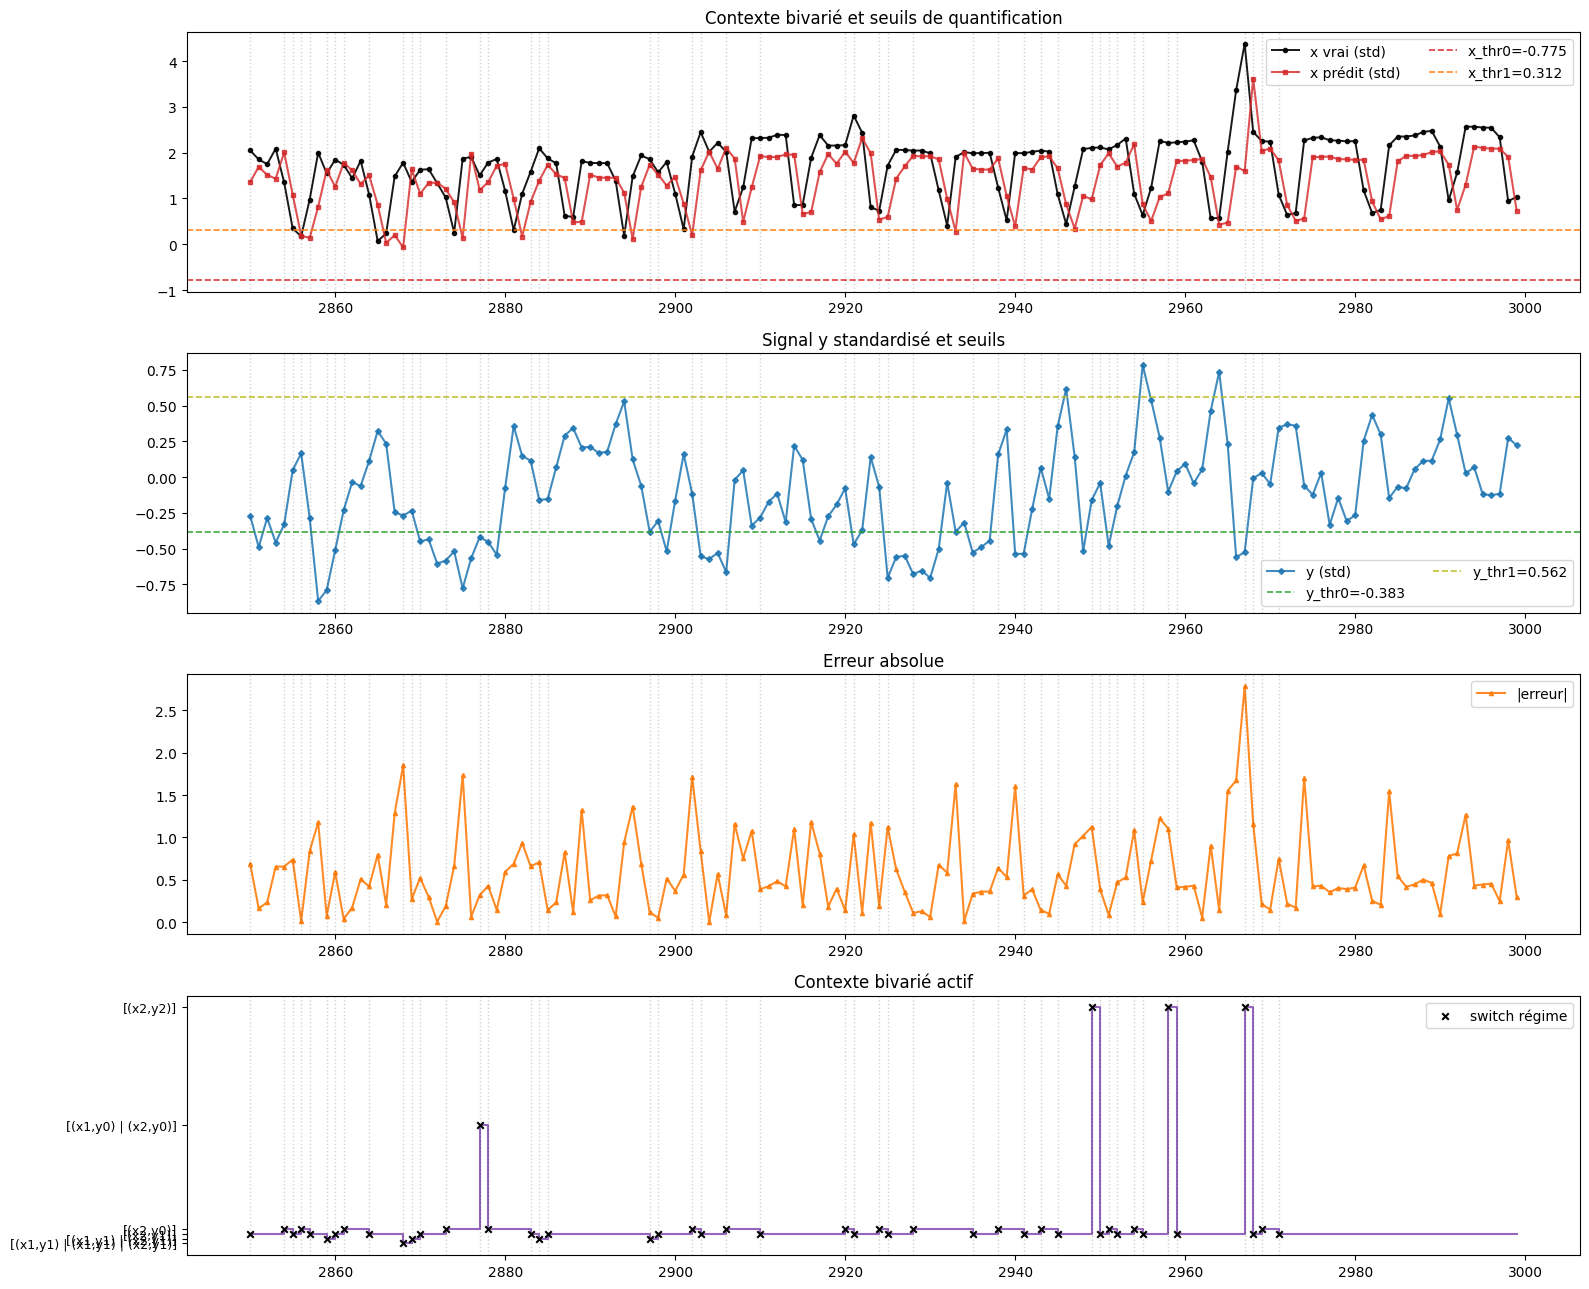

{'codes': array([0, 0, 0, ..., 5, 5, 5], shape=(3000,)),
 'code_to_label': {0: '[(x1,y2) | (x1,y2) | (x1,y2)]',
  1: '[(x1,y2) | (x1,y2) | (x1,y1)]',
  2: '[(x1,y2) | (x1,y1)]',
  3: '[(x1,y1) | (x1,y1) | (x2,y1)]',
  4: '[(x1,y1) | (x2,y1)]',
  5: '[(x2,y1)]',
  6: '[(x2,y0)]',
  7: '[(x1,y1) | (x1,y1) | (x1,y1)]',
  8: '[(x1,y1) | (x1,y1) | (x1,y2)]',
  9: '[(x1,y1) | (x1,y2)]',
  10: '[(x1,y1) | (x1,y1) | (x0,y2)]',
  11: '[(x1,y1) | (x0,y2) | (x0,y2)]',
  12: '[(x0,y2) | (x0,y2) | (x0,y2)]',
  13: '[(x0,y2) | (x0,y2) | (x0,y1)]',
  14: '[(x0,y2) | (x0,y1)]',
  15: '[(x0,y1) | (x0,y1) | (x0,y1)]',
  16: '[(x0,y1) | (x0,y1) | (x0,y2)]',
  17: '[(x0,y1) | (x0,y2)]',
  18: '[(x0,y1) | (x1,y1)]',
  19: '[(x1,y1) | (x1,y1) | (x1,y0)]',
  20: '[(x1,y1) | (x1,y0)]',
  21: '[(x1,y0) | (x1,y1)]',
  22: '[(x1,y0) | (x1,y0) | (x1,y0)]',
  23: '[(x1,y0) | (x1,y0) | (x0,y0)]',
  24: '[(x1,y0) | (x0,y0) | (x0,y0)]',
  25: '[(x0,y0)]',
  26: '[(x1,y0) | (x1,y0) | (x2,y0)]',
  27: '[(x1,y0) | (x2,y

In [40]:
fit_bi = fit_bivariate_for_trace(seq_x, seq_y, split=0.7)
bi = trace_bivariate_regimes(seq_x, seq_y, split=0.7, online=False)

actuals_bi_std = (bi["actuals"] - fit_bi["mu_x"]) / fit_bi["std_x"]
preds_bi_std = (bi["predictions"] - fit_bi["mu_x"]) / fit_bi["std_x"]

plot_bivariate_context_with_thresholds_std_markers(
    x_scaled=fit_bi["x_scaled"],
    y_scaled=fit_bi["y_scaled"],
    actuals_scaled=actuals_bi_std,
    predictions_scaled=preds_bi_std,
    contexts=bi["contexts"],
    quantizer=fit_bi["quantizer"],
    split_idx=bi["split_idx"],
    window_plot=150,
)


In [41]:
import numpy as np
import matplotlib.pyplot as plt


def plot_bivariate_context_with_regime_colors(
    x_scaled,
    y_scaled,
    actuals_scaled,
    predictions_scaled,
    contexts,
    quantizer,
    split_idx,
    window_plot=200,
    compact=True,
    max_tick_labels=12,
    title="Régimes bivariés actifs",
):
    x_scaled = np.asarray(x_scaled, dtype=float)
    y_scaled = np.asarray(y_scaled, dtype=float)
    actuals_scaled = np.asarray(actuals_scaled, dtype=float)
    predictions_scaled = np.asarray(predictions_scaled, dtype=float)

    y_test = y_scaled[split_idx:split_idx + len(actuals_scaled)]
    errors = np.abs(predictions_scaled - actuals_scaled)

    x_thr = np.asarray(quantizer.quantizers[0]._thresholds, dtype=float)
    y_thr = np.asarray(quantizer.quantizers[1]._thresholds, dtype=float)

    codes, code_to_label = contexts_to_codes_and_labels(
        contexts,
        quantizer=quantizer,
        kind="bivariate",
        compact=compact,
    )

    n = len(actuals_scaled)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    visible_codes = np.unique(codes[s:n])
    cmap = plt.cm.get_cmap("tab20", max(20, len(visible_codes)))
    color_map = {c: cmap(i % cmap.N) for i, c in enumerate(visible_codes)}

    switch_mask = np.zeros(len(codes), dtype=bool)
    if len(codes) > 1:
        switch_mask[1:] = codes[1:] != codes[:-1]
    switches = np.where(switch_mask)[0]
    visible_switches = switches[(switches >= s) & (switches < n)]

    plt.figure(figsize=(16, 12))

    ax1 = plt.subplot(4, 1, 1)

    # zones colorées par régime
    start = s
    current = codes[s]
    for t in range(s + 1, n + 1):
        if t == n or codes[t] != current:
            ax1.axvspan(start, t - 1, color=color_map[current], alpha=0.18)
            if t < n:
                start = t
                current = codes[t]

    ax1.plot(
        idx, actuals_scaled[s:n],
        label="x vrai (std)",
        color="black",
        linewidth=1.4,
        alpha=0.9,
        marker="o",
        markersize=3,
    )
    ax1.plot(
        idx, predictions_scaled[s:n],
        label="x prédit (std)",
        color="tab:red",
        alpha=0.8,
        marker="s",
        markersize=3,
    )

    for i, thr in enumerate(x_thr):
        ax1.axhline(
            thr,
            color=["tab:red", "tab:orange", "tab:pink", "tab:brown"][i % 4],
            linestyle="--",
            alpha=0.9,
            linewidth=1.1,
            label=f"x_thr{i}={thr:.3f}",
        )

    for sw in visible_switches:
        ax1.axvline(sw, color="black", linestyle=":", alpha=0.2, linewidth=1.0)

    ax1.legend(loc="best", ncol=2)
    ax1.set_title(title)

    ax2 = plt.subplot(4, 1, 2, sharex=ax1)
    ax2.plot(
        idx, y_test[s:n],
        label="y (std)",
        color="tab:blue",
        alpha=0.85,
        marker="D",
        markersize=3,
    )
    for i, thr in enumerate(y_thr):
        ax2.axhline(
            thr,
            color=["tab:green", "tab:olive", "tab:cyan", "tab:blue"][i % 4],
            linestyle="--",
            alpha=0.9,
            linewidth=1.1,
            label=f"y_thr{i}={thr:.3f}",
        )
    for sw in visible_switches:
        ax2.axvline(sw, color="black", linestyle=":", alpha=0.2, linewidth=1.0)
    ax2.legend(loc="best", ncol=2)
    ax2.set_title("y standardisé")

    ax3 = plt.subplot(4, 1, 3, sharex=ax1)
    ax3.plot(
        idx, errors[s:n],
        label="|erreur|",
        color="tab:orange",
        alpha=0.9,
        marker="^",
        markersize=3,
    )
    for sw in visible_switches:
        ax3.axvline(sw, color="black", linestyle=":", alpha=0.2, linewidth=1.0)
    ax3.legend(loc="best")
    ax3.set_title("Erreur absolue")

    ax4 = plt.subplot(4, 1, 4, sharex=ax1)
    ax4.step(idx, codes[s:n], where="post", color="tab:purple", linewidth=1.5)
    if len(visible_switches) > 0:
        ax4.scatter(
            visible_switches,
            codes[visible_switches],
            s=24,
            color="black",
            marker="x",
            label="switch régime",
            zorder=3,
        )
        ax4.legend()

    if len(visible_codes) <= max_tick_labels:
        ax4.set_yticks(visible_codes)
        ax4.set_yticklabels([code_to_label[c] for c in visible_codes], fontsize=9)
    else:
        ax4.set_yticks(visible_codes)
        ax4.set_yticklabels([str(c) for c in visible_codes], fontsize=9)
        print("Correspondance code -> contexte visible :")
        for c in visible_codes:
            print(f"  {c}: {code_to_label[c]}")

    ax4.set_title("Contexte quantifié actif")

    plt.tight_layout()
    plt.show()

    return {
        "codes": codes,
        "code_to_label": code_to_label,
        "visible_codes": visible_codes,
        "switches": switches,
        "color_map": color_map,
    }


/var/folders/dr/v65kt4vd74b0bqgk5_sy5npr0000gn/T/ipykernel_308/3210989227.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(20, len(visible_codes)))


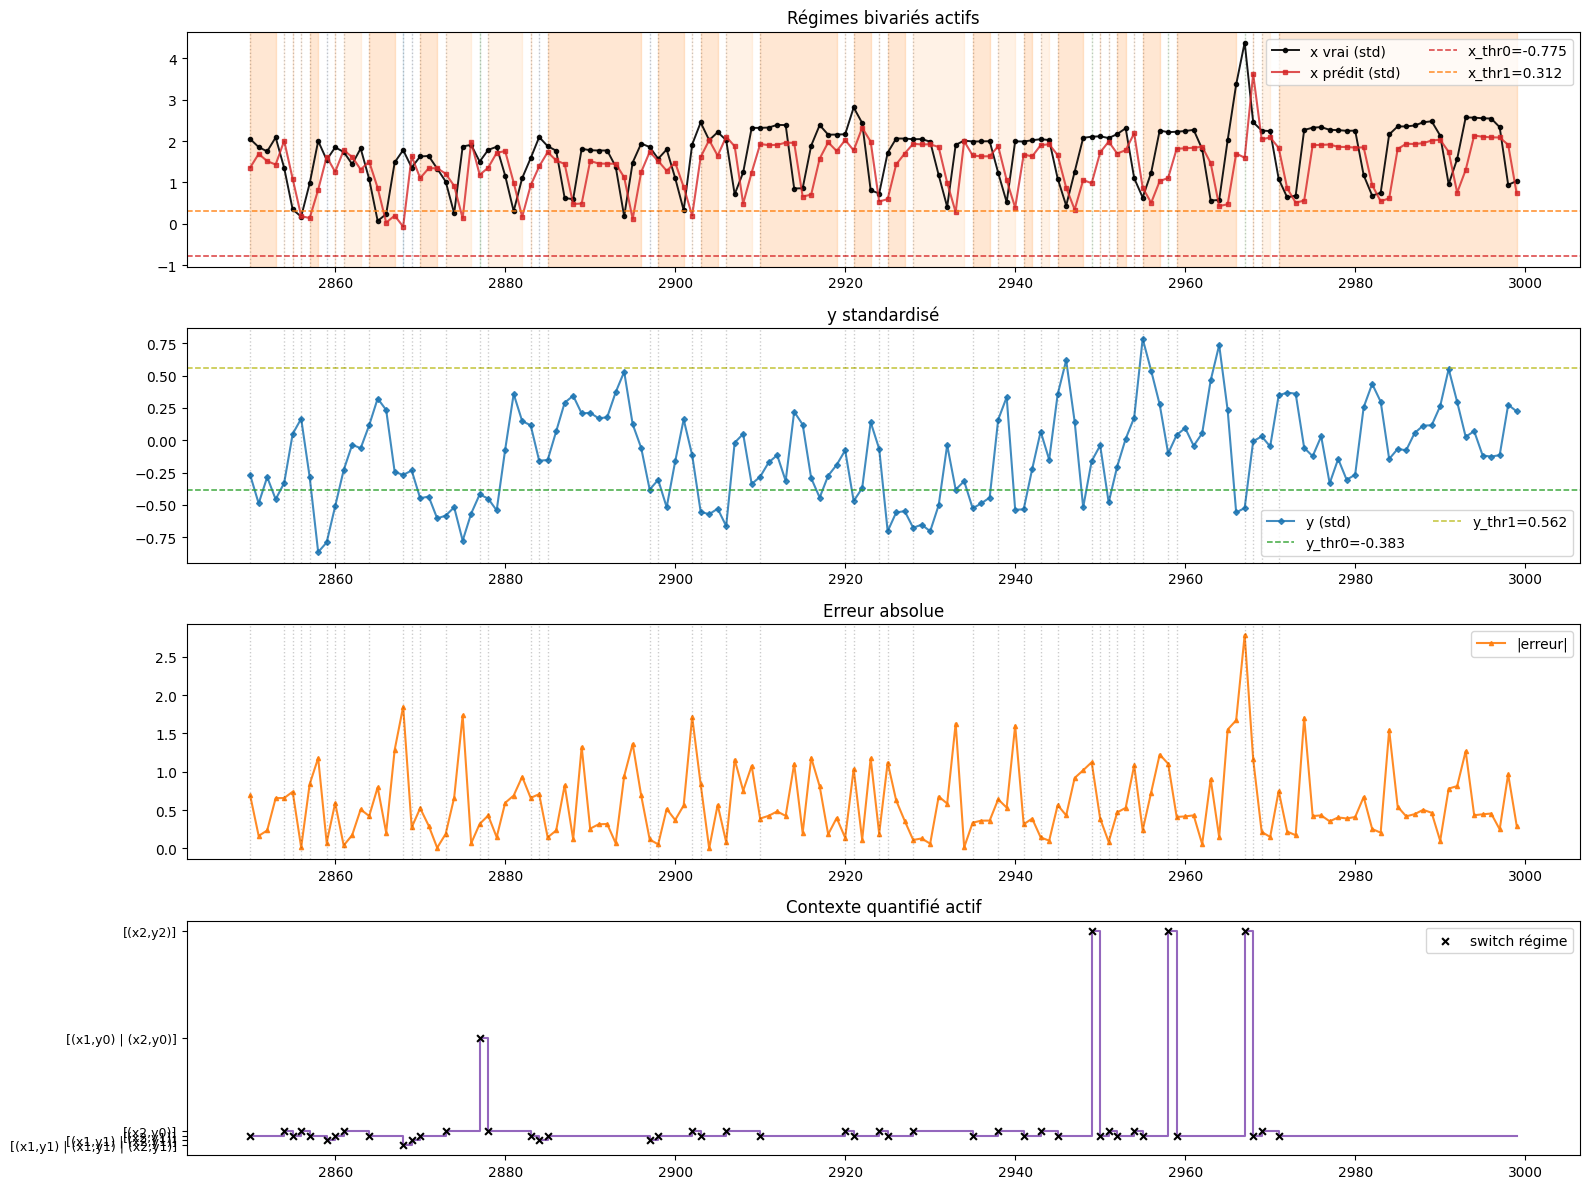

{'codes': array([0, 0, 0, ..., 5, 5, 5], shape=(3000,)),
 'code_to_label': {0: '[(x1,y2) | (x1,y2) | (x1,y2)]',
  1: '[(x1,y2) | (x1,y2) | (x1,y1)]',
  2: '[(x1,y2) | (x1,y1)]',
  3: '[(x1,y1) | (x1,y1) | (x2,y1)]',
  4: '[(x1,y1) | (x2,y1)]',
  5: '[(x2,y1)]',
  6: '[(x2,y0)]',
  7: '[(x1,y1) | (x1,y1) | (x1,y1)]',
  8: '[(x1,y1) | (x1,y1) | (x1,y2)]',
  9: '[(x1,y1) | (x1,y2)]',
  10: '[(x1,y1) | (x1,y1) | (x0,y2)]',
  11: '[(x1,y1) | (x0,y2) | (x0,y2)]',
  12: '[(x0,y2) | (x0,y2) | (x0,y2)]',
  13: '[(x0,y2) | (x0,y2) | (x0,y1)]',
  14: '[(x0,y2) | (x0,y1)]',
  15: '[(x0,y1) | (x0,y1) | (x0,y1)]',
  16: '[(x0,y1) | (x0,y1) | (x0,y2)]',
  17: '[(x0,y1) | (x0,y2)]',
  18: '[(x0,y1) | (x1,y1)]',
  19: '[(x1,y1) | (x1,y1) | (x1,y0)]',
  20: '[(x1,y1) | (x1,y0)]',
  21: '[(x1,y0) | (x1,y1)]',
  22: '[(x1,y0) | (x1,y0) | (x1,y0)]',
  23: '[(x1,y0) | (x1,y0) | (x0,y0)]',
  24: '[(x1,y0) | (x0,y0) | (x0,y0)]',
  25: '[(x0,y0)]',
  26: '[(x1,y0) | (x1,y0) | (x2,y0)]',
  27: '[(x1,y0) | (x2,y

In [42]:
fit_bi = fit_bivariate_for_trace(seq_x, seq_y, split=0.7)
bi = trace_bivariate_regimes(seq_x, seq_y, split=0.7, online=False)

actuals_bi_std = (bi["actuals"] - fit_bi["mu_x"]) / fit_bi["std_x"]
preds_bi_std = (bi["predictions"] - fit_bi["mu_x"]) / fit_bi["std_x"]

plot_bivariate_context_with_regime_colors(
    x_scaled=fit_bi["x_scaled"],
    y_scaled=fit_bi["y_scaled"],
    actuals_scaled=actuals_bi_std,
    predictions_scaled=preds_bi_std,
    contexts=bi["contexts"],
    quantizer=fit_bi["quantizer"],
    split_idx=bi["split_idx"],
    window_plot=150,
)
